<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🎵 Spotify Analysis 📈
    </h1>
</div>


# 📂 Overview

**Background**

This dataset contains **user activity and subscription data from Spotify**, one of the world’s leading music streaming platforms.
It includes details about **user demographics, engagement behavior, listening patterns, and device preferences**.

The dataset is designed for **customer churn analysis** — identifying which users are most likely to **cancel their subscription or stop using Spotify Premium**.

Understanding churn is vital for Spotify and similar streaming platforms due to:

* **High marketing costs** associated with acquiring new users.
* **Subscription-based revenue**, which depends on user retention.
* **Engagement-driven lifetime value (LTV)** models.
* The need for **personalized recommendations and retention strategies** in a competitive market.

**Goal of the Project**

Build a machine learning model to:

* **Predict churn** based on user demographics, engagement, and listening patterns.
* Identify **key behavioral indicators** that contribute to churn.
* Provide **data-driven insights** for improving retention, marketing targeting, and product experience.

**Key Features**

| Feature Name            | Description                                                      |
| ----------------------- | ---------------------------------------------------------------- |
| `user_id`               | Unique identifier for each Spotify user                          |
| `gender`                | Gender of the user (Male/Female/Other)                           |
| `age`                   | Age of the user                                                  |
| `country`               | Country or region of the user                                    |
| `subscription_type`     | Type of Spotify plan (Free, Premium, Family, etc.)               |
| `listening_time`        | Total listening time (in minutes) for the user                   |
| `songs_played_per_day`  | Average number of songs played per day                           |
| `skip_rate`             | Proportion of songs skipped during listening sessions            |
| `device_type`           | Device used for listening (Mobile, Desktop, Smart Speaker, etc.) |
| `ads_listened_per_week` | Number of advertisements listened per week (for free users)      |
| `offline_listening`     | Indicates if the user uses offline listening (1 = Yes, 0 = No)   |
| `is_churned`            | Target variable: `1` = Churned user, `0` = Active user           |

**Files Provided**

* `spotify_churn_dataset.csv`: Main dataset containing user demographics, engagement metrics, and churn labels.

**Project Objective**

The goal of this notebook is to **analyze, model, and predict user churn** in Spotify’s user base to help optimize customer retention strategies.

**Key Steps**

* **Exploratory Data Analysis (EDA):**
  Explore user demographics, behavior trends, and churn distribution.

* **Modeling:**
  Build and compare classification models:

  * Logistic Regression / Random Forest / XGBoost.
  * Ensemble techniques for better prediction accuracy.

* **Evaluation Framework:**

  * Use **cross-validation** for robust performance.
  * Focus on churn-specific metrics such as:

    * **AUC-ROC** – model discrimination.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [2]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical functions
from scipy.stats import skew, kurtosis, probplot

# Display utilities for Jupyter notebooks
from IPython.display import display, HTML

# Machine learning preprocessing and modeling
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Metrics
from sklearn.metrics import (roc_curve, roc_auc_score, classification_report, confusion_matrix,
                             precision_recall_curve, auc, average_precision_score)

# Statistical
from scipy.stats import chi2_contingency
from scipy.stats import probplot
from scipy.stats import kruskal
import scikit_posthocs as sp
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import levene
from scipy import stats
import pingouin as pg
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 500) # To display all the columns of dataframe
pd.set_option("max_colwidth", None) # To set the width of the column to maximum

In [3]:
class Config:
    SEED = 42
    MAX_ITER = 50000
    N_SPLIT = 1
    TEST_SIZE = 0.2

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [4]:
# Load the datasets
df = pd.read_csv("/kaggle/input/spotify-dataset-for-churn-analysis/spotify_churn_dataset.csv")

# Verify shapes
print("Data Shape:", df.shape)

Data Shape: (8000, 12)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
# Display few rows of dataset
print("Data Preview:")
display(df.head())

Data Preview:


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [6]:
# Replace space to under score.
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


## Insights from Initial Data Exploration

**Dataset Size and Structure**  
   - The **dataset** contains **8000** samples with **12** columns, including the target variable `is_churned`.

**Feature Overview**  
   - Both datasets include all important attributes:
     - **Numerical features:** `age`, `listening_time`, `songs_played_per_day`, `skip_rate`, `ads_listened_per_week`.
     - **Categorical features:** `offline_listening`, `gender`, `country`, `subscription_type`, `device_type`.
   - The target variable is **categorical** variable (`is_churned`).

**Data Completeness**  
   - The dataset have **no missing values**.
   - Data types are appropriate: numerical features are int64 and float64 and categorical features is object.
   - The column `user_id` is not meaningful for analysis. So this column is not really a part of the information we should care about. We can drop this column for data.

In [7]:
df.drop("user_id", axis=1, inplace=True)
num_features = ["age", "listening_time", "songs_played_per_day", "ads_listened_per_week"]
print("Data describe:")
cm = sns.light_palette("blue", as_cmap=True)
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

Data describe:


,count,mean,std,min,25%,50%,75%,max
age,8000.000000,37.662125,12.740359,16.000000,26.000000,38.000000,49.000000,59.000000
listening_time,8000.000000,154.068250,84.015596,10.000000,81.000000,154.000000,227.000000,299.000000
songs_played_per_day,8000.000000,50.127250,28.449762,1.000000,25.000000,50.000000,75.000000,99.000000
ads_listened_per_week,8000.000000,6.943875,13.617953,0.000000,0.000000,0.000000,5.000000,49.000000


## Descriptive Insights from Dataset Statistics

* **Age:** ranges from **16 to 59 years**, mean ≈ **37.7**, std ≈ **12.7** → Spotify users span multiple generations, with a balanced mix of young adults and mid-age listeners.
  The median age (38) suggests a slightly older audience base compared to typical streaming platforms.

* **Listening Time:** ranges from **10 to 299 minutes**, mean ≈ **154 mins/day**, std ≈ **84.0** → broad variability in engagement intensity.
  Around half of users listen **~2.5 hours daily**, while top quartile users exceed **3.5 hours/day**, reflecting high loyalty and streaming frequency.

* **Songs Played per Day:** ranges from **1 to 99**, mean ≈ **50**, std ≈ **28.4** → moderate-to-high daily activity.
  Median (50) aligns closely with mean → balanced user listening behavior without strong skewness.

* **Ads Listened per Week:** ranges from **0 to 49**, mean ≈ **6.9**, std ≈ **13.6** → large dispersion indicates diverse user base across **Free** (ad-supported) and **Premium** (ad-free) subscribers.
  Many users report zero ads (Premium users), confirming expected subscription heterogeneity.

**Summary**

Overall, the dataset presents **well-distributed and realistic engagement metrics**:

* **Listening behaviors** show healthy variability across users.
* **No extreme outliers** or distributional inconsistencies observed, indicating **clean and stable data** suitable for churn modeling and behavioral segmentation.

In [8]:
print("\nData describe:")
cat_features = ["offline_listening", "gender", "country", "subscription_type", "device_type"]
def convert_cat(features, df = df):
    for feature in features:
        if feature in df.columns:
            df[feature] = df[feature].astype("category")
convert_cat(cat_features)

display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))


Data describe:


,count,unique,top,freq
offline_listening,8000,2,1,5982
gender,8000,3,Male,2691
country,8000,8,AU,1034
subscription_type,8000,4,Premium,2115
device_type,8000,3,Desktop,2778


## Descriptive Insights for Categorical Features

* **Gender:** 3 categories → **Male** dominates (≈34%), indicating a slight gender imbalance among users.
* **Country:** 8 regions represented → **AU (Australia)** most frequent, showing geographic concentration.
* **Subscription Type:** 4 categories → **Premium (26%)** is the largest group, consistent with high offline usage.
* **Device Type:** 3 categories → **Desktop (35%)** most common, followed by mobile and smart devices.
* **Offline Listening:** 2 values → about **75%** of users use offline mode, reflecting strong Premium adoption.

=> Overall, the dataset captures a **diverse yet Premium-skewed user base**, suitable for analyzing churn behaviors across **device, region, and plan segments**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [9]:
def displayNULL(df, dataset_name=None):
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]
    missing_df = missing_df[missing_df["Missing_Count"] > 0]
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

    total_missing = missing_df["Missing_Count"].sum()

    print("=" * 40)
    if dataset_name:
        print(f"🔎 Missing Value Summary for: {dataset_name}")
    else:
        print("🔎 Missing Value Summary:")
    print("=" * 40)
    
    if total_missing == 0:
        print(f"✅ No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, colalign=("left", "left", "left")))
        except ImportError:
            print(missing_df.to_string(index=False))
        
        print(f"\n⚠️  Total missing values: {total_missing:,} out of {total_rows:,} rows.")

displayNULL(df, dataset_name="Dataset")

🔎 Missing Value Summary for: Dataset
✅ No missing values detected in 8,000 rows.


## Checking duplicate Value

In [10]:
def check_duplicates_report(df, dataset_name):
    duplicates_count = df.duplicated().sum()
    total_rows = len(df)
    
    print("=" * 40)
    print(f"🔍 {dataset_name} Duplicate Analysis")
    print("=" * 40)
    
    if duplicates_count == 0:
        print(f"✅ No duplicates found in {total_rows:,} rows")
    else:
        print(f"⚠️  {duplicates_count} duplicates found ({duplicates_count/total_rows:.2%})")
        print(f"    Total rows affected: {duplicates_count:,}/{total_rows:,}")

datasets = {
    "Data": df
}

duplicate_summary = {}
for name, data in datasets.items():
    check_duplicates_report(data, name)
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }

🔍 Data Duplicate Analysis
✅ No duplicates found in 8,000 rows


## Checking Outlier Value

In [11]:
def checking_outlier(list_feature, df, dataset_name):
    print("=" * 40)
    print(f"🔍 {dataset_name} Checking outlier")
    print("=" * 40)
    outlier_info = []
    
    for feature in list_feature:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        
        if len(outliers) > 0:
            outlier_info.append({
                "Feature": feature,
                "Outlier Count": len(outliers),
                # "Outlier Detail": outliers.tolist()
            })

    if len(outlier_info) == 0:
        print("✅ No outliers detected in the selected features.")
    else:
        return pd.DataFrame(outlier_info)

checking_outlier(list_feature=num_features, df=df, dataset_name="Data")

🔍 Data Checking outlier


,Feature,Outlier Count
0,ads_listened_per_week,1683


## Data Quality Insights: Missing Values, Duplicates and Outliers.

**Missing Values Analysis**

* We conducted a thorough examination for missing values in the dataset.

* **No missing values** were detected — ensuring clean synthetic data for model training.

**Duplicate Records Analysis**

* We performed a check for exact duplicate rows that could artificially inflate performance or introduce bias.

  * **No duplicates** detected in 2512 rows — ensuring test predictions are made on unique samples.

**Outlier Analysis**

* We also examined the datasets for checking outliers.
* **The outliers** were found in dataset at features. But we can not remove them since these outliers reflect reality.
* The datasets contain **notable outliers** in `ads_listened_per_week`.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


| **Data Distribution**          | **Variance Across Groups** | **Test for ≥ 3 Groups** | **Test for 2 Groups**   | **Test Type**      |
| ------------------------------ | -------------------------- | ----------------------- | ----------------------- | ------------------ |
| ✅ Normal & ✅ Equal Variances   | Classical **ANOVA**        | Classical **t-test**    | **Parametric**          |                    |
| ✅ Normal & ❌ Unequal Variances | **Welch’s ANOVA**          | **Welch’s t-test**      | **Robust Parametric**   |                    |
| ❌ Non-Normal                   | (Any)                      | **Kruskal–Wallis**      | **Mann–Whitney U test** | **Non-Parametric** |


In [12]:
def color(n_colors=2):
    return sns.color_palette("RdYlGn", n_colors=n_colors)

In [13]:
def cal_ChiSquare(cat_feature, target_feature, df, show_expected=False, show_residuals=False):
    """
    Perform a Chi-Square test of independence to evaluate whether two categorical variables
    are statistically associated (i.e., dependent) or independent from each other.

    This function tests the null hypothesis that the two categorical variables are independent.
    It prints the test statistic, degrees of freedom, p-value, and an interpretation based on the p-value.
    Optionally, it displays the expected frequency table under independence, and standardized residuals
    (including a heatmap) which help to identify specific group-level deviations.

    Parameters
    ----------
    cat_feature : str
        Name of the first categorical variable (typically the feature).

    target_feature : str
        Name of the second categorical variable (typically the target label).

    df : pd.DataFrame
        The input DataFrame containing the data.

    show_expected : bool, default=False
        If True, prints the expected frequencies under the assumption of independence.

    show_residuals : bool, default=False
        If True, prints the standardized residuals and shows them as a heatmap
        to identify where the strongest associations/deviations occur.

    Returns
    -------
    None
        Prints the Chi-Square test result, including statistical significance interpretation.
        Optionally prints expected values and standardized residuals.

    Notes
    -----
    - Hypotheses:
        H₀ (Null):     The two variables are independent (no association).
        H₁ (Alt.):      There is a dependency or association between the variables.

    - Interpretation:
        If p-value < 0.05 → Reject H₀ → Conclude that the variables are significantly associated.
        If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant association found.

    - Standardized residuals:
        - Values > +2 or < -2 indicate strong deviation from expected frequency (local dependency).
        - Useful for identifying specific group-level contributions to the overall Chi-Square result.

    References
    ----------
    - https://en.wikipedia.org/wiki/Chi-squared_test
    - https://www.scribbr.com/statistics/chi-square-test-of-independence/
    """
    print(f"\n🔍 Chi-Square Test of Independence: '{cat_feature}' vs. '{target_feature}'")

    # Contingency table
    crosstab = pd.crosstab(df[cat_feature], df[target_feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    print(f"Chi-squared statistic: {chi2:.3f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p:.6f}")

    if p < 0.05:
        print("✅ Result: p-value < 0.05 → Reject H₀")
        print(f"→ There is a **statistically significant association** between '{cat_feature}' and '{target_feature}'.")
    else:
        print("❎ Result: p-value ≥ 0.05 → Fail to reject H₀")
        print(f"→ No statistically significant association between '{cat_feature}' and '{target_feature}'.")

    # Optional: show expected frequencies
    if show_expected:
        print("\n📊 Expected Frequencies:")
        print(pd.DataFrame(expected, index=crosstab.index, columns=crosstab.columns))
    else:
        pass

    # Optional: show standardized residuals
    if show_residuals:
        cmap = sns.color_palette("RdYlGn", as_cmap=True)
        residuals = (crosstab - expected) / np.sqrt(expected)
        print("\n📈 Standardized Residuals:")
        print(round(residuals, 2))

        # Heatmap of residuals
        plt.figure(figsize=(10, 5))
        sns.heatmap(residuals, annot=True, cmap=cmap, center=0, fmt=".2f", linewidths=0.5)
        plt.title(f"Standardized Residuals Heatmap: {cat_feature} vs {target_feature}", weight="bold", fontsize=13, pad=25)
        plt.ylabel(cat_feature)
        plt.xlabel(target_feature)
        plt.tight_layout()
        plt.show()

def perform_kruskal_test(df, categorical_feature, numeric_feature):
    """
    Perform the Kruskal-Wallis H-test to determine whether there are statistically
    significant differences in the distribution of a numeric variable across
    three or more independent groups.

    If the result is significant (p < 0.05), Dunn's post-hoc test with Bonferroni correction
    is performed to identify which group pairs differ.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the categorical and numerical variables.

    categorical_feature : str
        The name of the categorical feature that defines the groups.

    numeric_feature : str
        The name of the numeric feature to be compared across groups.

    Returns
    -------
    None
        Prints the Kruskal-Wallis H-statistic, p-value, interpretation, and
        optionally the results of Dunn's post-hoc test.

    Notes
    -----
    - H₀ (null hypothesis): The distribution of the numeric variable is the same across all groups.
    - H₁ (alternative hypothesis): At least one group has a different distribution.
    - If p < 0.05 → reject H₀ → use Dunn’s test to explore specific group differences.
    - Kruskal-Wallis is a non-parametric alternative to one-way ANOVA.
    - It does not assume normality, but assumes:
        1. Independent samples
        2. Ordinal or continuous response variable
        3. Similar shapes of distributions

    Requirements
    ------------
    - `scipy.stats.kruskal`
    - `scikit-posthocs` package for Dunn’s test (`import scikit_posthocs as sp`)

    References
    ----------
    - https://www.geeksforgeeks.org/kruskal-wallis-test/
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html
    - https://scikit-posthocs.readthedocs.io/en/latest/index.html
    """

    # Extract values
    groups = df[categorical_feature].dropna().unique()
    if len(groups) < 3:
        print(f"❌ Error: Kruskal-Wallis H-test requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 Kruskal-Wallis Test: {numeric_feature} ~ {categorical_feature}")
        data_groups = [df[df[categorical_feature] == g][numeric_feature].dropna() for g in groups]

        # Perform kruskal
        stat, p = kruskal(*data_groups)

        print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
        print(f"p-value: {p}")

        if p < 0.05:
            print("🟢 Significant difference found. Running Dunn's Post-Hoc Test...")
            dunn_result = sp.posthoc_dunn(df, val_col=numeric_feature, group_col=categorical_feature, p_adjust="bonferroni")
            print(dunn_result)
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def check_normality_with_plots(df, feature, target_feature, threshold_skew_1=0.5, threshold_skew_2=1.0,
                               threshold_kurt=1.5, ncols=2):
    """
    Check the normality of numerical features *within each group* of a categorical feature,
    using Skewness, Kurtosis, and Q–Q plots. 
    If non-normality is detected in any group, automatically perform Kruskal–Wallis test.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing both numeric and categorical features.

    feature : numeric
        Numerical columns to test (e.g. ["Temparature"]).

    target_feature : str
        Categorical variable name (e.g. "Fertilizer_Name").

    threshold_skew_1 : float, default = 0.5
        Threshold for approximately symmetric (|skew| ≤ 0.5).

    threshold_skew_2 : float, default = 1.0
        Threshold for moderate skewness (0.5 < |skew| ≤ 1.0).

    threshold_kurt : float, default = 1.5
        Absolute kurtosis threshold for approximate normality.

    ncols : int, default = 2
        Number of Q–Q plots per row.
    """

    results = []
    non_normal_detected = False

    print(f"\n Checking normality of numeric feature(s) by target feature: '{target_feature}'")

    # ===  Evaluate normality within each group ===
    print(f"\n🔹 Feature: {feature}")

    for grp, subset in df.groupby(target_feature):
        data = subset[feature].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        abs_sk = abs(sk)
        abs_kt = abs(kt)

        # Skewness interpretation
        if abs_sk <= threshold_skew_1:
            skew_remark = "Approximately symmetric"
        elif abs_sk <= threshold_skew_2:
            skew_remark = "Moderately skewed"
        else:
            skew_remark = "Highly skewed"

        # Kurtosis interpretation
        if abs_kt < threshold_kurt:
            kurt_remark = "Normal tails"
        else:
            kurt_remark = "Heavy/light tails"

        remark = f"{skew_remark}, {kurt_remark}"
        results.append({
            "Feature": feature,
            "Group": grp,
            "Skewness": f"{sk:.4f}",
            "Kurtosis": f"{kt:.4f}",
            "Remark": remark
        })

        # Flag if any group is not approximately normal
        if not (abs_sk <= threshold_skew_1 and abs_kt <= threshold_kurt):
            non_normal_detected = True

    # === Visual Q–Q plots ===
    n_groups = df[target_feature].nunique()
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, grp in enumerate(df[target_feature].unique()):
        ax = axes[i]
        data = df.loc[df[target_feature] == grp, feature].dropna()
        probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{feature} — {grp}", fontsize=11, weight="bold")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Q–Q Plots of {feature} by {target_feature}", fontsize=13, weight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # === Display results table ===
    df_result = pd.DataFrame(results)
    styled = (
        df_result.style
        .background_gradient(subset=["Skewness"], cmap=cm, vmin=-1, vmax=1)
        .background_gradient(subset=["Kurtosis"], cmap=cm, vmin=-1.5, vmax=1.5)
        .set_caption(
            f'<b><span style="font-size:14px; text-align:center; display:block;">'
            f'Skewness & Kurtosis of {feature} by {target_feature}'
            f'</span></b>'
        )
        .set_table_attributes('style="width:80%; margin:auto;"')
    )
    display(styled)

    if non_normal_detected == True:
        print("\n⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...")
    else:
        print("\n✅ All groups approximately follow normal distribution.")

    return non_normal_detected

def perform_anova_with_tukey(df, numeric_feature, categorical_feature, typ=2):
    """
    Perform a One-Way ANOVA test to determine whether there are statistically
    significant differences between the means of three or more independent groups.

    If the ANOVA test is significant (p < 0.05), Tukey's HSD post-hoc test is performed
    to identify which specific pairs of groups differ from each other.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing the numeric and categorical features.

    numeric_feature : str
        The name of the numerical (continuous) response variable.

    categorical_feature : str
        The name of the categorical (independent) variable used to group the data.

    typ : int, optional (default=2)
        The type of sum of squares to use in the ANOVA test:
        - Type I (1): Sequential.
        - Type II (2): Default and commonly used for balanced designs.
        - Type III (3): Use when model includes interaction terms or unbalanced data.

    Returns
    -------
    None
        Prints the ANOVA table, p-value, interpretation, and (if significant) the Tukey HSD test summary.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean is different.
    - If p < 0.05 → reject H₀ → perform Tukey’s HSD to find which groups differ.
    - Assumptions:
        1. Independence of observations
        2. Normally distributed groups (Shapiro or Anderson test can check this)
        3. Homogeneity of variances (Levene's test)

    References
    ----------
    - https://www.scribbr.com/statistics/one-way-anova/
    - https://en.wikipedia.org/wiki/Analysis_of_variance
    - https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
    """

    # Extract unique groups
    groups = df[categorical_feature].dropna().unique()

    if len(groups) < 3:
        print(f"❌ Error: ANOVA requires 3 or more groups.")
        return
    else:
        print(f"\n🔍 ANOVA Test: {numeric_feature} ~ {categorical_feature} (Type {typ})")

        # Fit OLS model
        model = ols(f"{numeric_feature} ~ C({categorical_feature})", data=df).fit()

        # Perform ANOVA
        anova_table = anova_lm(model, typ=typ)
        print("\n📊 ANOVA Table:")
        print(anova_table)

        # Extract p-value
        p_value = anova_table["PR(>F)"].iloc[0]

        if p_value < 0.05:
            print("\n✅ Significant difference found (p < 0.05)")
            print("➡️ Performing Tukey's HSD post-hoc test:")

            tukey = pairwise_tukeyhsd(df[numeric_feature], df[categorical_feature])
            print(tukey.summary())
        else:
            print("\nℹ️ No significant difference found (p >= 0.05)")

def perform_welch_anova(df, numeric_feature, categorical_feature):
    """
    Perform Welch’s ANOVA test to compare group means when the assumption of equal variances
    is violated but normality approximately holds.

    This version of ANOVA adjusts for unequal variances and sample sizes across groups.
    If the Welch’s ANOVA is significant (p < 0.05), a Games–Howell post-hoc test is performed
    to identify which specific group pairs differ significantly.

    Parameters
    ----------
    df : pd.DataFrame
        The input dataset containing both numeric and categorical variables.

    numeric_feature : str
        The name of the continuous (dependent) variable.

    categorical_feature : str
        The name of the categorical (independent) variable representing group membership.

    Returns
    -------
    None
        Prints Welch’s ANOVA summary, p-value interpretation, and Games–Howell post-hoc results.

    Notes
    -----
    - H₀ (null hypothesis): All group means are equal.
    - H₁ (alternative hypothesis): At least one group mean differs.
    - If p < 0.05 → reject H₀ → perform Games–Howell test.
    - Assumptions:
        1. Groups are independent.
        2. Data within each group are approximately normal.
        3. Variances are not necessarily equal (heteroscedasticity allowed).

    Key Differences vs Classical ANOVA
    ----------------------------------
    - Welch’s ANOVA does **not assume equal variances**.
    - More robust when sample sizes and variances differ across groups.
    - Use **Games–Howell post-hoc test** instead of Tukey HSD.

    References
    ----------
    - Welch, B. L. (1951). "On the comparison of several mean values: an alternative approach."
      Biometrika, 38(3/4), 330–336.
    - Games, P. A., & Howell, J. F. (1976). "Pairwise multiple comparison procedures with unequal N’s and/or variances."
      Journal of Educational Statistics, 1(2), 113–125.
    """

    # Drop NaN rows
    df = df[[numeric_feature, categorical_feature]].dropna()

    # Extract group values
    groups = [df.loc[df[categorical_feature] == g, numeric_feature] for g in df[categorical_feature].unique()]

    if len(groups) < 3:
        print("❌ Error: Welch’s ANOVA requires 3 or more groups.")
        return

    print(f"\n🔍 Welch’s ANOVA Test: {numeric_feature} ~ {categorical_feature}")
    print("Testing mean differences under heteroscedasticity assumption...")

    # Perform Welch's ANOVA (scipy.stats)
    welch_result = stats.f_oneway(*groups)
    print("\nWelch’s ANOVA Result:")
    print(f"F-statistic = {welch_result.statistic:.4f},  p-value = {welch_result.pvalue:.6f}")

    # Interpret result
    if welch_result.pvalue < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
        print("➡️ Performing Games–Howell post-hoc test:\n")

        # Perform Games–Howell post-hoc test (robust for unequal variances)
        gh_result = pg.pairwise_gameshowell(dv=numeric_feature, between=categorical_feature, data=df)
        # display(gh_result)

        display(HTML("<b>Games–Howell Post-hoc Test (adjusted p-values)</b>"))
        display(gh_result.style.background_gradient(cmap=cm).format(precision=4).set_table_attributes('style="width:80%; margin:auto;"'))
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")


def check_homogeneity_of_variance(df, feature, target_feature, alpha=0.05, ratio_threshold=2.0):
    """
    Check homogeneity of variances across groups using Levene’s test (median-centered).
    Also computes variance ratios and provides practical interpretation.

    ---
    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing numeric and categorical features.
    feature : str
        Numeric variable to test (e.g. "Temparature").
    target_feature : str
        Categorical grouping variable (e.g. "Fertilizer_Name").
    alpha : float, default = 0.05
        Significance level for hypothesis testing.
    ratio_threshold : float, default = 2.0
        Threshold for maximum acceptable variance ratio (max(var)/min(var)).
        If ratio > threshold → indicates heteroscedasticity in practice.

    ---
    Returns
    -------
    dict
        Dictionary with test statistic, p-value, variance ratio, and recommendation.

    ---
    Interpretation Logic
    ---------------------
    Step 1: Statistical Test
        - H₀: All group variances are equal.
        - H₁: At least one group has a different variance.
        - Levene’s Test (center='median') is robust to non-normality.

    Step 2: Practical Variance Ratio
        - ratio = max(var_i) / min(var_i)
        - < 2 → practically equal
        - 2–4 → moderate difference
        - > 4 → strong heterogeneity

    Step 3: Recommendation
        - If p > 0.05 AND ratio < 2 → ANOVA suitable
        - If p < 0.05 BUT ratio < 2 → Statistical diff, but practically negligible → still OK for ANOVA
        - If ratio ≥ 2 OR p < 0.05  →  Use Welch’s ANOVA or Kruskal–Wallis
    """

    # Group data by category
    groups = [df.loc[df[target_feature] == g, feature].dropna() for g in df[target_feature].unique()]

    # Perform Levene’s Test (robust version)
    stat, p = levene(*groups, center="mean")

    # Compute variance ratio (max/min)
    variances = [np.var(g, ddof=1) for g in groups]
    ratio = max(variances) / min(variances)
    anova_use = False
    is_homogeneous_variances = False
    # Determine interpretation
    if p > alpha and ratio < ratio_threshold:
        status = "✅ Homogeneous variances."
        recommendation = "Use One-Way ANOVA or Independent Two-Sample T-Test."
        is_homogeneous_variances = True
        anova_use = True
    elif p < alpha and ratio < ratio_threshold:
        status = "⚠️ Statistically significant difference, but practically small — ANOVA or T-Test still acceptable."
        recommendation = "Use Welch’s ANOVA or Welch’s T-Test."
        anova_use = True
    else:
        status = "🚨 Variances differ substantially — Use non-parametric test."
        recommendation = "Use Kruskal–Wallis or Mann–Whitney U test (Wilcoxon rank-sum test)."

    # Display summary table
    summary_df = pd.DataFrame({
        "Metric": ["Levene’s Statistic", "p-value", "Max/Min Variance Ratio"],
        "Value": [f"{stat:.4f}", f"{p:.6f}", f"{ratio:.2f}"]
    })
    display(summary_df.style
            .background_gradient(subset=["Value"], cmap="Blues")
            .set_caption(
        f'<b><span style="font-size:14px; text-align:center; display:block;">'
        f'Homogeneity of Variance — {feature} by {target_feature}</span></b>'
    ).set_table_attributes('style="width:70%; margin:auto;"'))

    # Print interpretation
    print("\n🔍 Interpretation:")
    print(f"   {status}")
    print(f"   Recommendation → {recommendation}")

    return anova_use, is_homogeneous_variances

def cal_mannwhitneyu(dataframe, categorical_feature, num_feature):
    """
    Perform the Mann–Whitney U test (Wilcoxon rank-sum test) to assess whether there 
    is a statistically significant difference in the distribution of a numerical feature 
    between two independent groups defined by a binary categorical feature.

    The function also compares medians, calculates the effect size (r), provides interpretation,

    Parameters
    ----------
    dataframe : pd.DataFrame
        The input DataFrame containing the data.

    categorical_feature : str
        Column name of the categorical feature (must contain exactly 2 unique values).

    num_feature : str
        Column name of the numerical feature to compare.

    Returns
    -------
    None
        Prints the U statistic, p-value, medians, Z-score, effect size r, and interpretation.

    Notes
    -----
    - H₀ (Null Hypothesis): The two groups have the same distribution.
    - H₁ (Alternative Hypothesis): The distributions are different.
    - If p ≤ 0.05 → reject H₀ → significant difference.
    - Effect size r helps interpret how strong the difference is:
        * Small ~0.1, Medium ~0.3, Large ≥0.5
    """

    groups = dataframe[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Mann-Whitney U test requires exactly 2 groups, but found {len(groups)}.")
        return

    print(f"🔍 Mann–Whitney U Test for '{num_feature}' by '{categorical_feature}'\n")

    group1 = dataframe[dataframe[categorical_feature] == groups[0]][num_feature].dropna()
    group2 = dataframe[dataframe[categorical_feature] == groups[1]][num_feature].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

    print(f"U statistic : {stat}")
    print(f"p-value     : {p}")

    # Interpretation
    if p <= 0.05:
        print("\n✅ Result: Statistically significant difference between the two groups (Reject H₀).")
        median1 = group1.median()
        median2 = group2.median()
        if median1 > median2:
            print(f" Interpretation: Group '{groups[0]}' has a higher median '{num_feature}' than Group '{groups[1]}'.")
        elif median1 < median2:
            print(f" Interpretation: Group '{groups[1]}' has a higher median '{num_feature}' than Group '{groups[0]}'.")
        else:
            print(" Interpretation: The medians are equal, but distributions may still differ.")
    else:
        print("\n⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).")

def t_test_with_cohens_d(data, categorical_feature, num_feature, equal_var=False):
    """
    Perform an Independent Two-Sample T-Test and compute Cohen's d to evaluate 
    the difference between two independent groups on a numeric variable.

    Supports both:
    - Student’s T-Test (equal variances)
    - Welch’s T-Test (unequal variances, default)

    Parameters
    ----------
    data : pd.DataFrame
        The input DataFrame containing the categorical and numerical features.

    categorical_feature : str
        The name of the categorical column used to define the two groups (must have exactly 2 unique values).

    num_feature : str
        The name of the numerical feature to compare between the two groups.

    equal_var : bool, optional (default=False)
        If True → Student’s t-test (equal variances).
        If False → Welch’s t-test (unequal variances).

    Returns
    -------
    None
        Prints the t-statistic, p-value, Cohen’s d, and interpretation of the effect size.

    Notes
    -----
    - H₀ (null hypothesis): The two groups have equal means.
    - H₁ (alternative): The group means differ significantly.
    - Cohen's d interpretation:
        - 0.2 → small effect
        - 0.5 → medium effect
        - 0.8+ → large effect
    - Welch’s t-test is recommended when group variances are unequal (default setting).

    References
    ----------
    - https://www.scribbr.com/statistics/t-test/
    - https://en.wikipedia.org/wiki/Welch%27s_t-test
    - https://en.wikipedia.org/wiki/Cohen%27s_d
    """

    # Extract unique groups
    groups = data[categorical_feature].dropna().unique()

    if len(groups) != 2:
        print(f"❌ Error: Independent T-Test requires exactly 2 groups.")
        return

    print(f"🔍 Independent Two-Sample T-Test: {num_feature} ~ {categorical_feature}")
    print(f"→ Test Type: {'Student’s T-Test (equal variances)' if equal_var else 'Welch’s T-Test (unequal variances)'}")

    # Extract values
    x1 = data[data[categorical_feature] == groups[0]][num_feature].dropna()
    x2 = data[data[categorical_feature] == groups[1]][num_feature].dropna()

    # Run T-Test
    t_stat, p_value = ttest_ind(x1, x2, equal_var=equal_var)

    # Calculate Cohen's d (different formulas depending on variance assumption)
    nx1, nx2 = len(x1), len(x2)
    s1, s2 = np.var(x1, ddof=1), np.var(x2, ddof=1)

    if equal_var:
        # --- Student’s T-Test version (pooled variance)
        pooled_std = np.sqrt(((nx1 - 1) * s1 + (nx2 - 1) * s2) / (nx1 + nx2 - 2))
        cohens_d = (np.mean(x1) - np.mean(x2)) / pooled_std
    else:
        # --- Welch’s T-Test version (average variance)
        s_pooled = np.sqrt((s1 + s2) / 2)
        cohens_d = (np.mean(x1) - np.mean(x2)) / s_pooled

    # Output
    print(f"\nComparing groups: '{groups[0]}' vs. '{groups[1]}'")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.6f}")
    print(f"Cohen's d: {cohens_d:.3f}")

    # Significance interpretation
    if p_value < 0.05:
        print("\n✅ Significant difference found (p < 0.05)")
    else:
        print("\nℹ️ No significant difference found (p ≥ 0.05)")

    # Effect size interpretation
    if abs(cohens_d) < 0.2:
        size = "small"
    elif abs(cohens_d) < 0.5:
        size = "medium"
    else:
        size = "large"

    print(f"Effect size interpretation: {size} effect ({abs(cohens_d)})")

## Churn Distribution

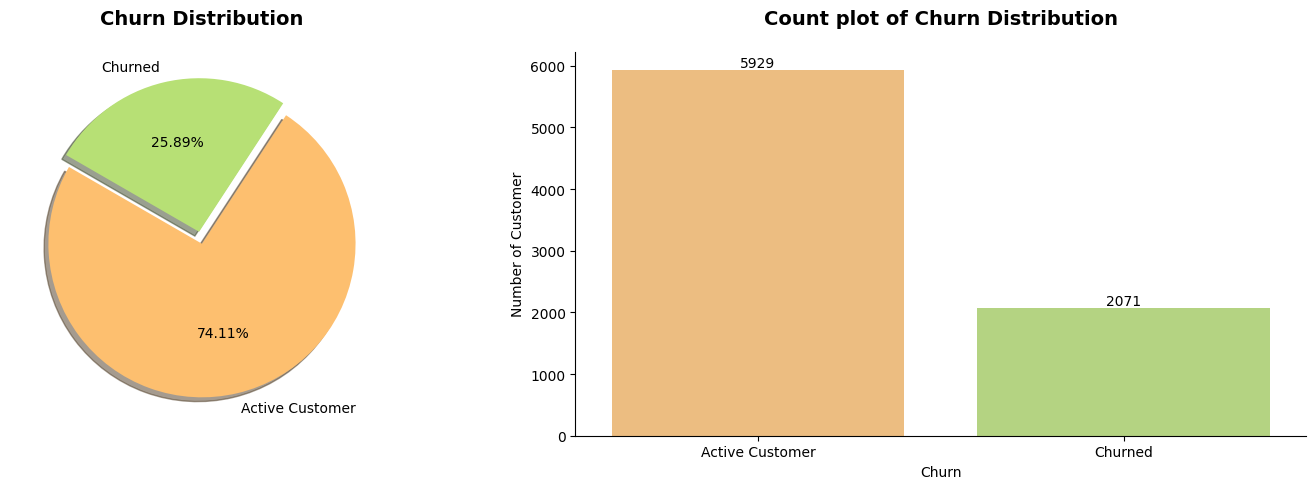

In [14]:
churn_Distribution  = df["is_churned"].value_counts()
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))
n_color = color(n_colors=df["is_churned"].nunique())
# ax[0]
ax[0].pie(churn_Distribution, labels = ["Active Customer", "Churned"], colors = n_color,  autopct = "%1.2f%%",
          startangle = 150, explode = (0, 0.08), shadow= True)
ax[0].set_title("Churn Distribution",  weight="bold", fontsize=14, pad=20)

# ax[1]
sns.countplot(data=df, x = "is_churned", palette=n_color, 
              ax=ax[1])
ax[1].set_title("Count plot of Churn Distribution", weight="bold", fontsize=14, pad=20)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10)
ax[1].set_ylabel("Number of Customer")
ax[1].set_xticks([0, 1], ["Active Customer", "Churned"])
ax[1].set_xlabel("Churn")
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

**Frequency of churn categories**

* The pie chart and count plot display the proportion of active vs. churned Spotify users.
* `Active Customer` represents **5,929 records (~74.11%)**.
* `Churned` users account for **2,071 records (~25.89%)**.

***The dataset is moderately imbalanced, with active users forming the majority group.***
This reflects a **typical real-world churn scenario**, where most users remain subscribed while a smaller fraction cancels or disengages.

## Numerical Feature Distributions

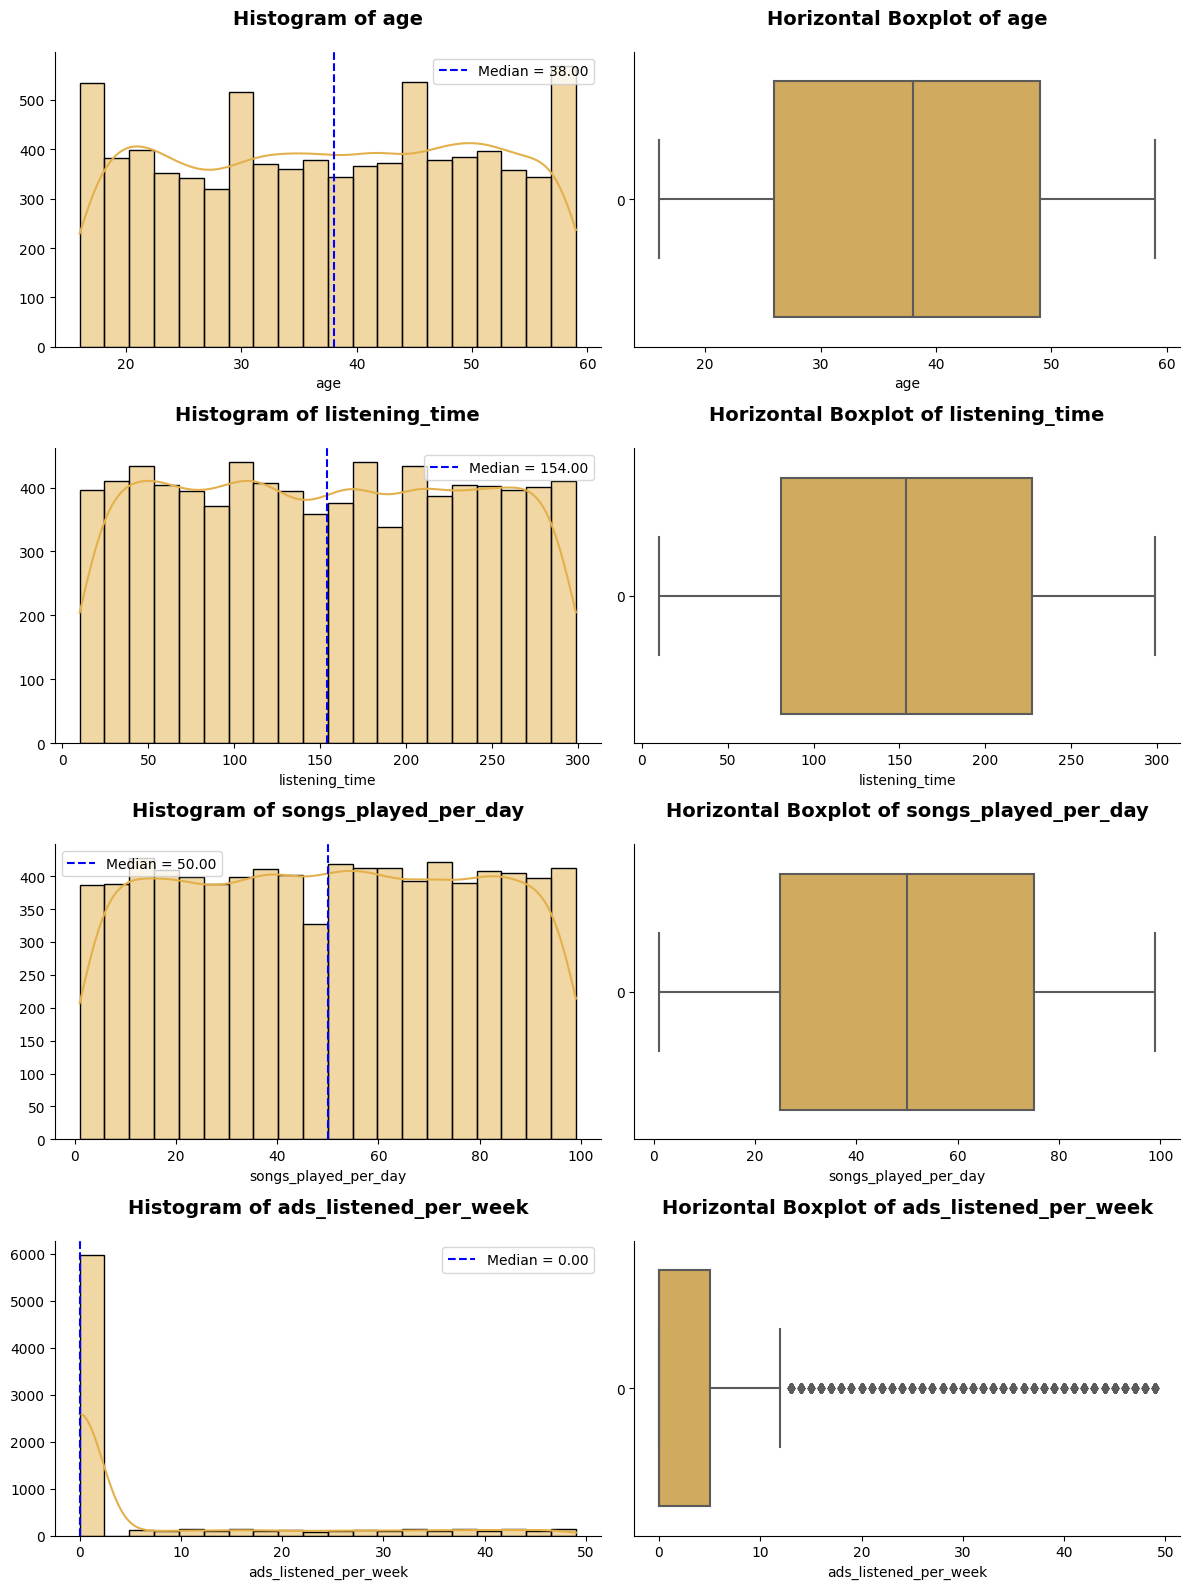

In [15]:
def plot_numerical_features(df=df, numerical_features = num_features):
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        sns.histplot(data=df[feature], color="#E3B04B", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", weight="bold", fontsize=14, pad=20)
        ax[i, 0].set_ylabel("")
        median_val = df[feature].median()
        ax[i, 0].axvline(median_val, color="blue", linestyle="--", label=f"Median = {median_val:.2f}")
        ax[i, 0].legend()
        sns.despine(ax=ax[i, 0], top=True, right=True, left=False, bottom=False)

        sns.boxplot(data=df[feature], color="#E3B04B", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Boxplot of {feature}", weight="bold", fontsize=14, pad=20)
        ax[i, 1].set_xlabel(feature)
        sns.despine(ax=ax[i, 1], top=True, right=True, left=False, bottom=False)

    plt.tight_layout()
    plt.show()

plot_numerical_features()

In [16]:
def check_skewness(data = df, numerical_features = num_features, highlight=True, sort=True):
    skewness_dict = {}
    skew_feature = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)
    else:
        pass
    
    print(f"\n🔍 Skewness for dataset:")
    print("-"*75)
    print(f"{'Feature':<35} | {'Skewness':<10} | {'Remark'}")
    print("-"*75)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            color = "\033[91m"  
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
            color = "\033[93m"  
        else:
            remark = "Approximately symmetric"
            color = ""
        endc = "\033[0m" if color else ""
        if highlight and color:
            print(f"{color}{feature:<35} | {skew:>+10f} | {remark}{endc}")
            skew_feature.append(feature)
        else:
            print(f"{feature:<35} | {skew:>+10f} | {remark}")
    print("-"*75)
    return skew_feature, skew_df

skew_feature, skew_df = check_skewness()


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
ads_listened_per_week               |  +1.799745 | Highly skewed
age                                 |  -0.027435 | Approximately symmetric
listening_time                      |  +0.009674 | Approximately symmetric
songs_played_per_day                |  -0.003661 | Approximately symmetric
---------------------------------------------------------------------------


**Shape and Spread of Distributions**

- **Histograms** reveal that all features are distributed fairly evenly across their respective ranges.
- **Boxplots** confirm that the central 50% of values (the interquartile range), and the whiskers (showing the range).

**Skewness Analysis**

- The dataset’s numerical features are mostly balanced and approximately symmetric → favorable for modeling.
- Only `ads_listened_per_week` shows highly skewness, which should be addressed when included in the model (via transformation or scaling).

## Correlation Analysis of Numerical Features

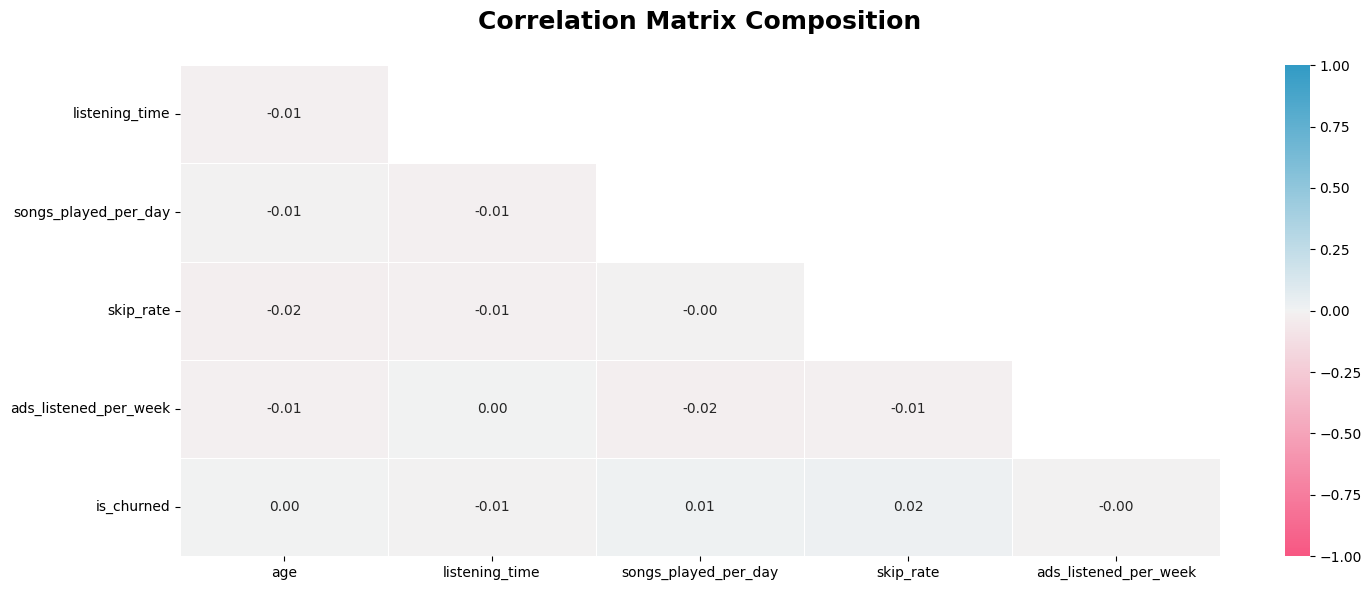

In [17]:
corr_matrix = df.corr(numeric_only=True)
# one_like can build a matrix of boolean(True, False) with the same shape as our data
ones_corr = np.ones_like(corr_matrix, dtype=bool)
mask = np.triu(ones_corr)
adjusted_mask = mask[1:, :-1]
adjusted_cereal_corr = corr_matrix.iloc[1:, :-1]

fig, ax = plt.subplots(figsize = (15, 6))
# That method uses HUSL colors, so you need hue, saturation, and lightness. 
# I used hsluv.org to select the colors of this chart.
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

sns.heatmap(data=adjusted_cereal_corr, mask=adjusted_mask,
            annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linecolor="white", linewidths=0.5)

title = "Correlation Matrix Composition\n"
ax.set_title(title, loc="center", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

* All numerical variables show **near-zero correlations** with each other (`|r| < 0.05`).
* Metrics such as `listening_time`, `songs_played_per_day`, `skip_rate`, and `ads_listened_per_week` are **mostly independent**, indicating they capture distinct aspects of user behavior.
* No multicollinearity is observed → all variables can be retained for modeling without redundancy issues.

***Overall, the numerical feature space is well-balanced and non-redundant, suitable for downstream modeling.***

## Categorical Feature Distributions

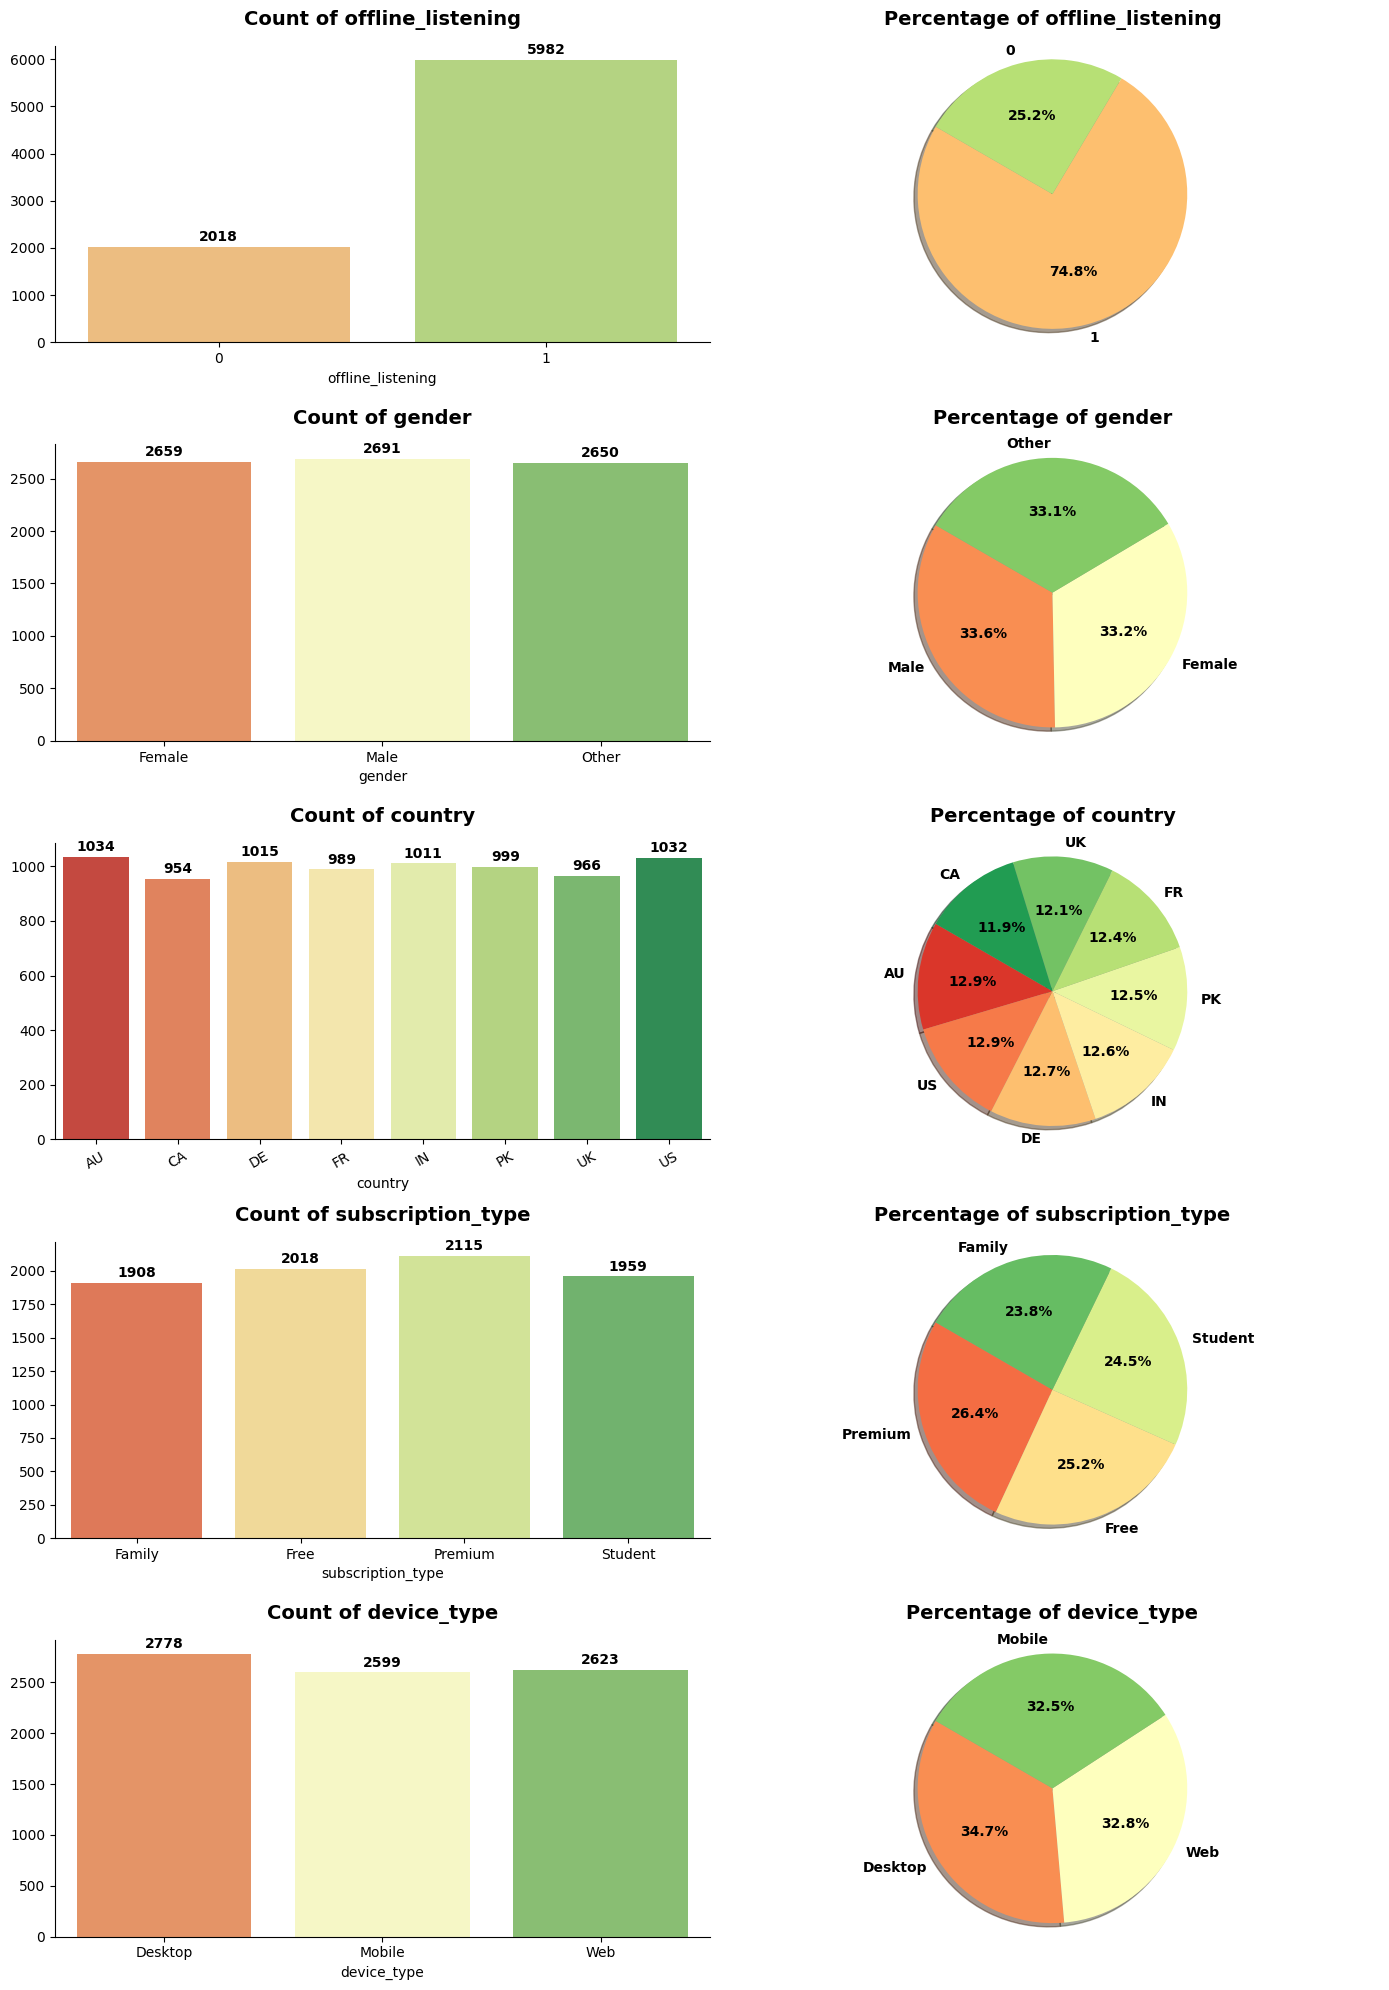

In [18]:
def plot_categorical_distribution(df, cat_features):
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(14, len(cat_features) * 4))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        # ----------------------------
        # LEFT: Countplot
        # ----------------------------
        sns.countplot(
            data=df, x=feature, ax=ax[i, 0],
            palette=color(n_colors=len(df[feature].unique()))
        )
        ax[i, 0].set_title(f"Count of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 0].set_xlabel(feature)
        ax[i, 0].set_ylabel("")
        if len(df[feature].unique()) > 4:
            ax[i, 0].set_xticklabels(ax[i, 0].get_xticklabels(), rotation=30)
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # ----------------------------
        # RIGHT: Pie Chart
        # ----------------------------
        feature_counts = df[feature].value_counts(normalize=True)
        labels = feature_counts.index
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=labels, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 10, "weight": "bold"}
        )
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=14, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    plt.tight_layout()
    plt.show()

plot_categorical_distribution(df=df, cat_features=cat_features)

**Descriptive Insights for Categorical Features**

* **Offline Listening:** ~75% of users enable offline mode → majority are **Premium users**, showing high engagement.
* **Gender:** Fairly balanced across groups (~33% each) → no major gender bias in user base.
* **Country:** Evenly distributed across 8 regions → dataset is **geographically diverse**.
* **Subscription Type:** Close distribution among Free (25%), Premium (26%), Student (24%), and Family (24%) → indicates **healthy mix of user tiers**.
* **Device Type:** Similar proportions between Desktop (35%), Mobile (33%), and Web (33%) → users access Spotify **equally across platforms**.

**Overall:**
The categorical variables show **well-balanced and diverse distributions**, ensuring **representative coverage of Spotify’s global user base** — ideal for churn and behavior segmentation analysis.

## Bivariate Analysis

,is_churned,Count,Mean,Median,Std
1,1,2071,37.747948,38.000000,12.677044
0,0,5929,37.632147,38.000000,12.763331



 Checking normality of numeric feature(s) by target feature: 'is_churned'

🔹 Feature: age


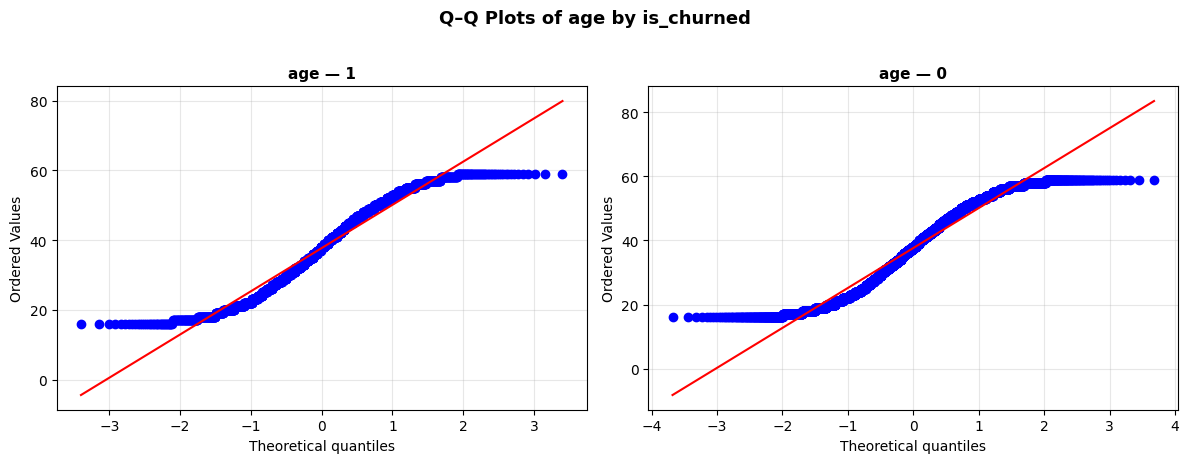

,Feature,Group,Skewness,Kurtosis,Remark
0,age,0,-0.0298,-1.2147,"Approximately symmetric, Normal tails"
1,age,1,-0.0202,-1.2010,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,0.1739
1,p-value,0.676661
2,Max/Min Variance Ratio,1.01



🔍 Interpretation:
   ✅ Homogeneous variances.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.
🔍 Independent Two-Sample T-Test: age ~ is_churned
→ Test Type: Student’s T-Test (equal variances)

Comparing groups: '1' vs. '0'
t-statistic: 0.356
p-value: 0.721794
Cohen's d: 0.009

ℹ️ No significant difference found (p ≥ 0.05)
Effect size interpretation: small effect (0.009088790511121481)


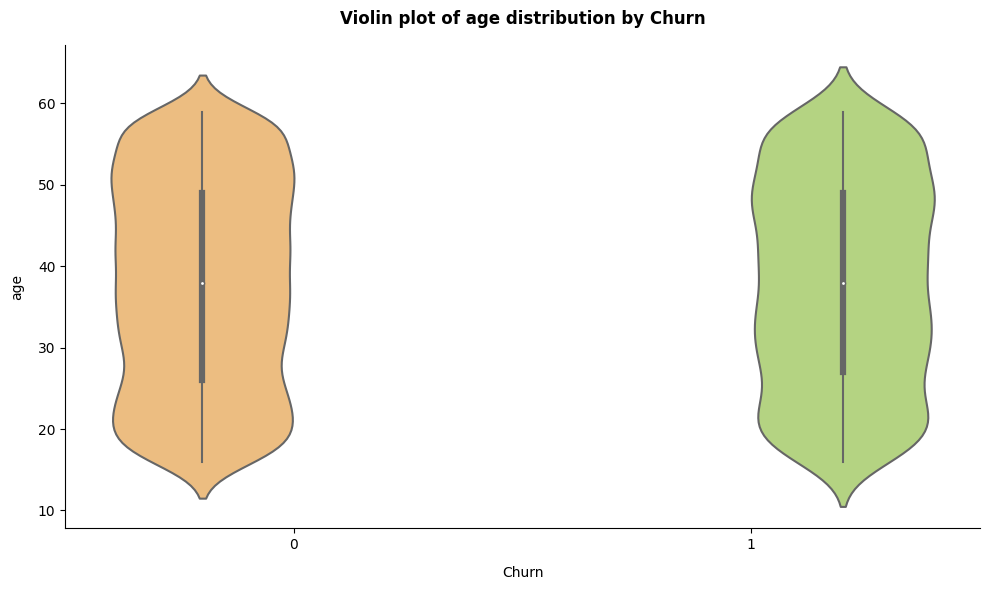

,is_churned,Count,Mean,Median,Std
0,0,5929,154.446787,155.000000,84.323276
1,1,2071,152.984549,153.000000,83.139146



 Checking normality of numeric feature(s) by target feature: 'is_churned'

🔹 Feature: listening_time


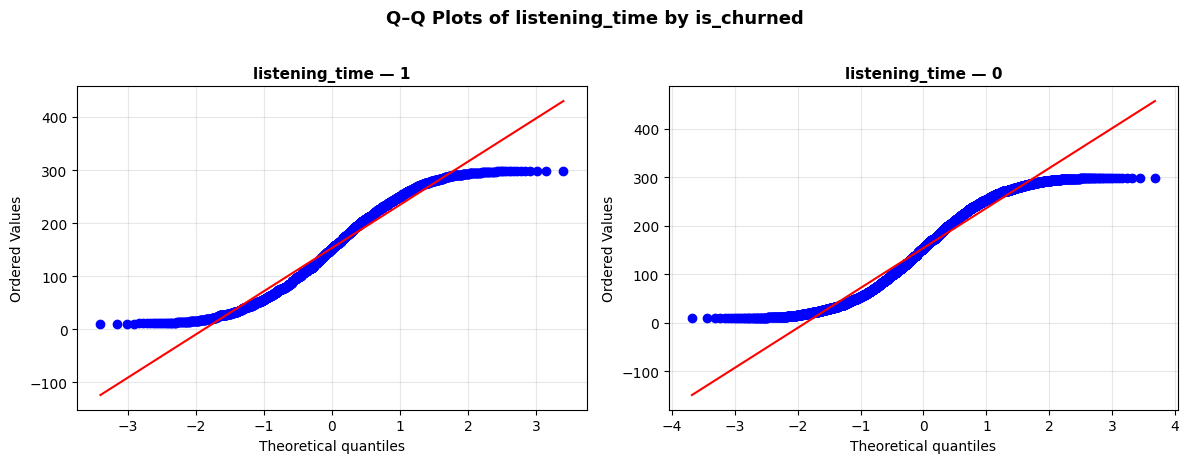

,Feature,Group,Skewness,Kurtosis,Remark
0,listening_time,0,0.0010,-1.2236,"Approximately symmetric, Normal tails"
1,listening_time,1,0.0345,-1.1846,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,1.3826
1,p-value,0.239698
2,Max/Min Variance Ratio,1.03



🔍 Interpretation:
   ✅ Homogeneous variances.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.
🔍 Independent Two-Sample T-Test: listening_time ~ is_churned
→ Test Type: Student’s T-Test (equal variances)

Comparing groups: '1' vs. '0'
t-statistic: -0.682
p-value: 0.495363
Cohen's d: -0.017

ℹ️ No significant difference found (p ≥ 0.05)
Effect size interpretation: small effect (0.017403786997603567)


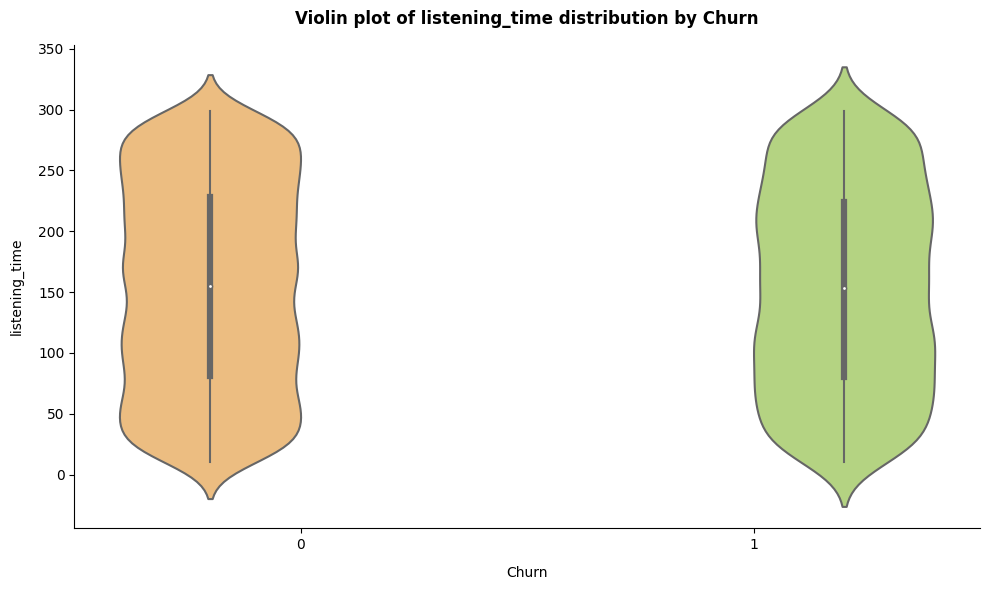

,is_churned,Count,Mean,Median,Std
1,1,2071,50.575567,52.000000,28.364024
0,0,5929,49.970653,50.000000,28.480374



 Checking normality of numeric feature(s) by target feature: 'is_churned'

🔹 Feature: songs_played_per_day


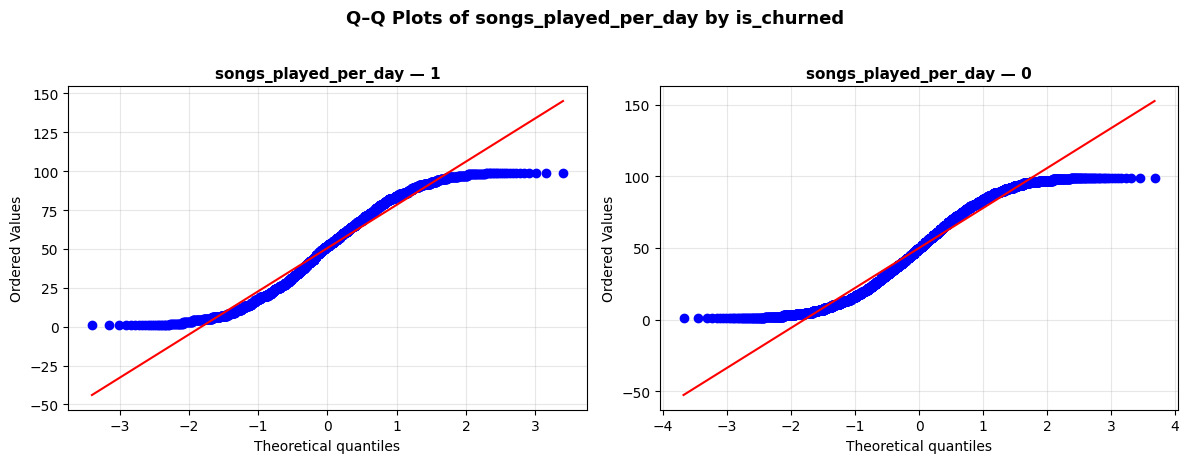

,Feature,Group,Skewness,Kurtosis,Remark
0,songs_played_per_day,0,0.0072,-1.1959,"Approximately symmetric, Normal tails"
1,songs_played_per_day,1,-0.0347,-1.1795,"Approximately symmetric, Normal tails"



✅ All groups approximately follow normal distribution.


,Metric,Value
0,Levene’s Statistic,0.1943
1,p-value,0.659401
2,Max/Min Variance Ratio,1.01



🔍 Interpretation:
   ✅ Homogeneous variances.
   Recommendation → Use One-Way ANOVA or Independent Two-Sample T-Test.
🔍 Independent Two-Sample T-Test: songs_played_per_day ~ is_churned
→ Test Type: Student’s T-Test (equal variances)

Comparing groups: '1' vs. '0'
t-statistic: 0.833
p-value: 0.404872
Cohen's d: 0.021

ℹ️ No significant difference found (p ≥ 0.05)
Effect size interpretation: small effect (0.021262148034684594)


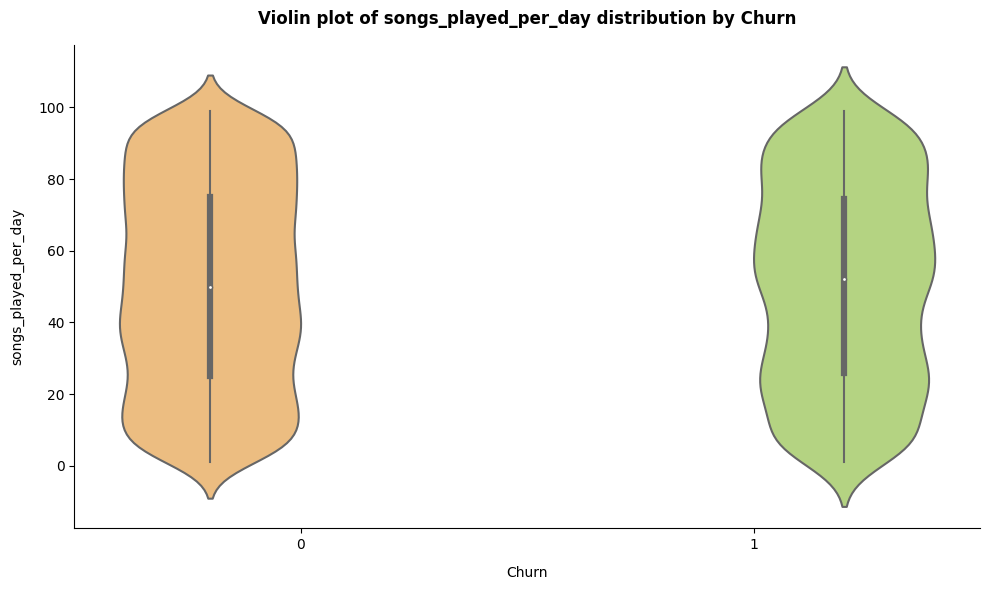

,is_churned,Count,Mean,Median,Std
0,0,5929,6.962220,0.000000,13.581398
1,1,2071,6.891357,0.000000,13.725229



 Checking normality of numeric feature(s) by target feature: 'is_churned'

🔹 Feature: ads_listened_per_week


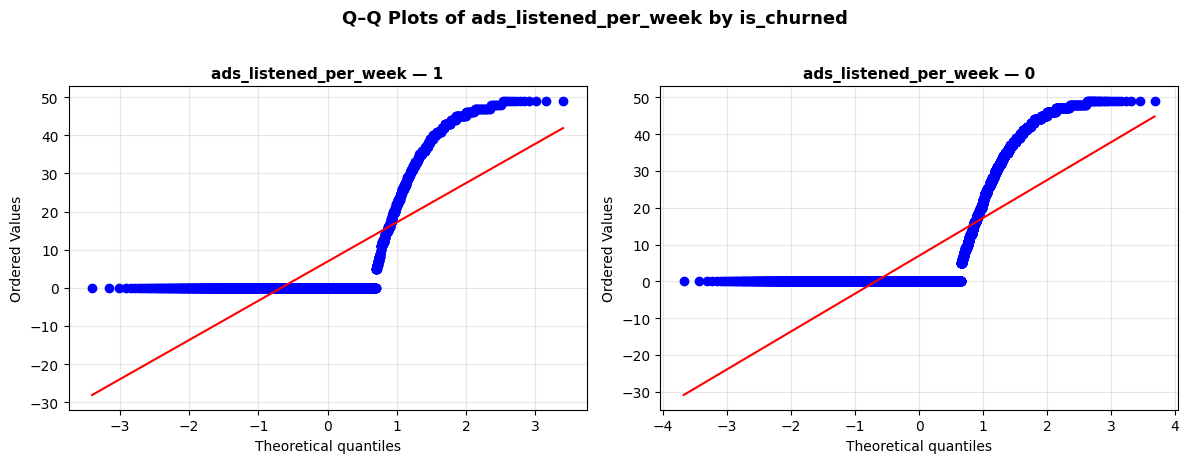

,Feature,Group,Skewness,Kurtosis,Remark
0,ads_listened_per_week,0,1.7935,1.7932,"Highly skewed, Heavy/light tails"
1,ads_listened_per_week,1,1.8159,1.8367,"Highly skewed, Heavy/light tails"



⚠️ At least one group deviates from normality → Running Kruskal–Wallis test or Mann–Whitney U test...
🔍 Mann–Whitney U Test for 'ads_listened_per_week' by 'is_churned'

U statistic : 6080982.0
p-value     : 0.3967093113708373

⚪ Result: No statistically significant difference between the two groups (Fail to reject H₀).


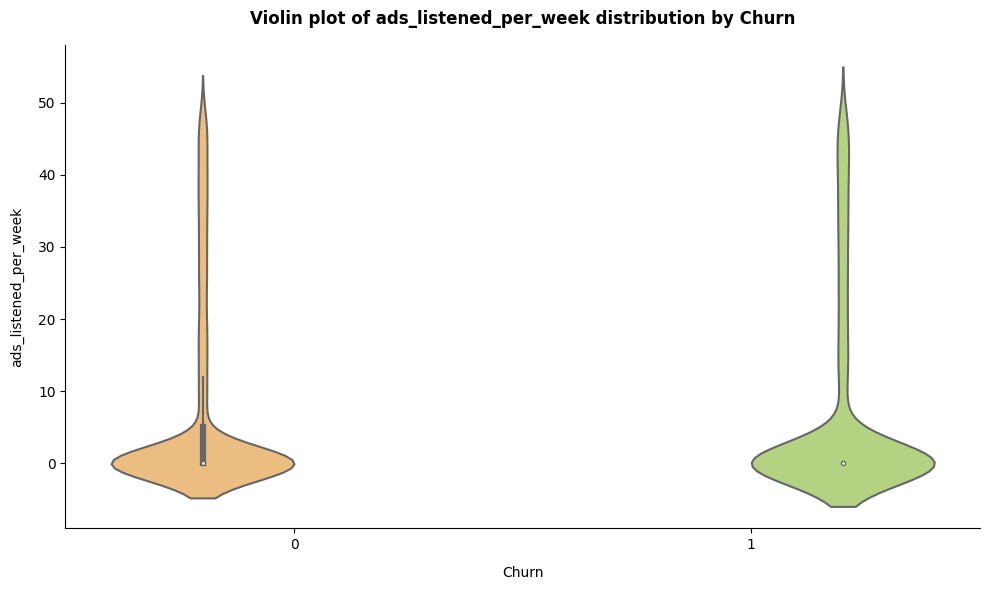

In [19]:
def perform_statical_testing(feature: str, df: pd.DataFrame = df,  target_feature: str = "is_churned") -> None:
    """
    Perform statistical tests (normality and Kruskal-Wallis) 
    to evaluate whether there are significant differences 
    in the distribution of a numerical feature across categories 
    of the target variable.

    Args:
        feature (str): Name of the numerical feature to be tested.
        df (pd.DataFrame): Dataset containing both numerical and target columns.
        target_feature (str): Name of the target categorical feature.

    Returns:
        None: Prints or displays statistical test results.
    """
    # Perform normality test (e.g., Shapiro-Wilk or D’Agostino test) for feature distribution
    non_normal_detected = check_normality_with_plots(df=df, feature=feature, target_feature=target_feature)
    total_categories = df[target_feature].nunique()
    if total_categories > 2:
        if non_normal_detected == True:
            perform_kruskal_test(df=df, categorical_feature=target_feature,
                                numeric_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                perform_anova_with_tukey(df=df, numeric_feature=feature,
                                        categorical_feature=target_feature)
            elif anove_use and is_homogeneous_variances == False:
                perform_welch_anova(df=df, numeric_feature=feature, categorical_feature=target_feature)
            else:
                perform_kruskal_test(df=df, categorical_feature=target_feature,
                        numeric_feature=feature)
    else:
        if non_normal_detected == True:
            cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)
        else:
            anove_use, is_homogeneous_variances = check_homogeneity_of_variance(df=df, feature=feature,
                                                                                target_feature=target_feature)
            if anove_use and is_homogeneous_variances:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=True)
            elif anove_use and is_homogeneous_variances == False:
                t_test_with_cohens_d(data=df, categorical_feature=target_feature, num_feature=feature, equal_var=False)
            else:
                cal_mannwhitneyu(dataframe=df, categorical_feature=target_feature, num_feature=feature)

def plot_numerical_distribution(feature: str, df: pd.DataFrame = df,
                                target_feature: str = "is_churned", order: list = None) -> None:
    """
    Perform statistical testing and visualize the distribution of a numerical feature 
    across different classes of the target variable using violin plots and summary statistics.

    The function executes:
      1. Statistical tests.
      2. Summary table with mean, median, std per category.
      3. Violin plot for visualizing feature distributions across classes.

    Args:
        feature (str): The name of the numerical feature to analyze.
        df (pd.DataFrame): Input dataframe containing numerical & target features.
        target_feature (str): Target variable name (categorical feature).
        order (list, optional): Custom ordering for category display in the plot.

    Returns:
        None: Displays statistical summaries and plots directly.
    """

    # Compute summary statistics for each Fertilizer category
    df_summary_feature = (
        df.groupby(by=target_feature, as_index=False)
        .agg(
            Count=(feature, "count"),
            Mean=(feature, "mean"),
            Median=(feature, "median"),
            Std=(feature, "std")
        )
        .sort_values(by="Mean", ascending=False)
    )

    # Compute global statistics for the entire feature
    summary_data = [
        ("Overall Mean", f"{df[feature].mean():.2f}"),
        ("Overall Median", f"{df[feature].median()}"),
        ("Overall Std", f"{df[feature].std():.2f}")
    ]

    # Display overall statistics in HTML format for better notebook visualization
    summary_html = "<ul>" + "".join([
        f"<li><b>{k}:</b> {v}</li>" for k, v in summary_data
    ]) + "</ul>"
    display(HTML(summary_html))

    # Display detailed summary per category as styled dataframe
    display(
        df_summary_feature.style.background_gradient(cmap=cm)
        .set_table_attributes('style="width:75%; margin:auto;"')
    )

    # Run statistical significance testing
    perform_statical_testing(feature=feature, target_feature=target_feature)

    # Visualize distribution via violin plot
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=target_feature, y=feature, data=df, hue=target_feature, order=order,
                   palette=color(n_colors=df[target_feature].nunique()))
    
    plt.title(f"Violin plot of {feature} distribution by Churn", pad=15, weight="bold")
    plt.xlabel("Churn", labelpad=10)
    plt.ylabel(feature, labelpad=10)
    plt.legend().remove()
    sns.despine(left=False, bottom=False)
    plt.tight_layout()
    plt.show()

for feature in num_features:
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {feature} by Churn</b></h2>"))
    plot_numerical_distribution(feature=feature, df = df)

### Insight Numerical Features by Churn

`age`

Age does not significantly influence churn in this dataset.

`listening_time` 

Listening time does not significantly influence churn behavior — both active and churned users spend comparable time listening on Spotify.

`songs_played_per_day` 

The number of songs played per day shows **no meaningful impact on churn** — user activity levels are consistent regardless of churn status.

`ads_listened_per_week`

Exposure to ads does **not significantly differ** between churned and active groups, implying **ad frequency is not a key churn driver** in this dataset.

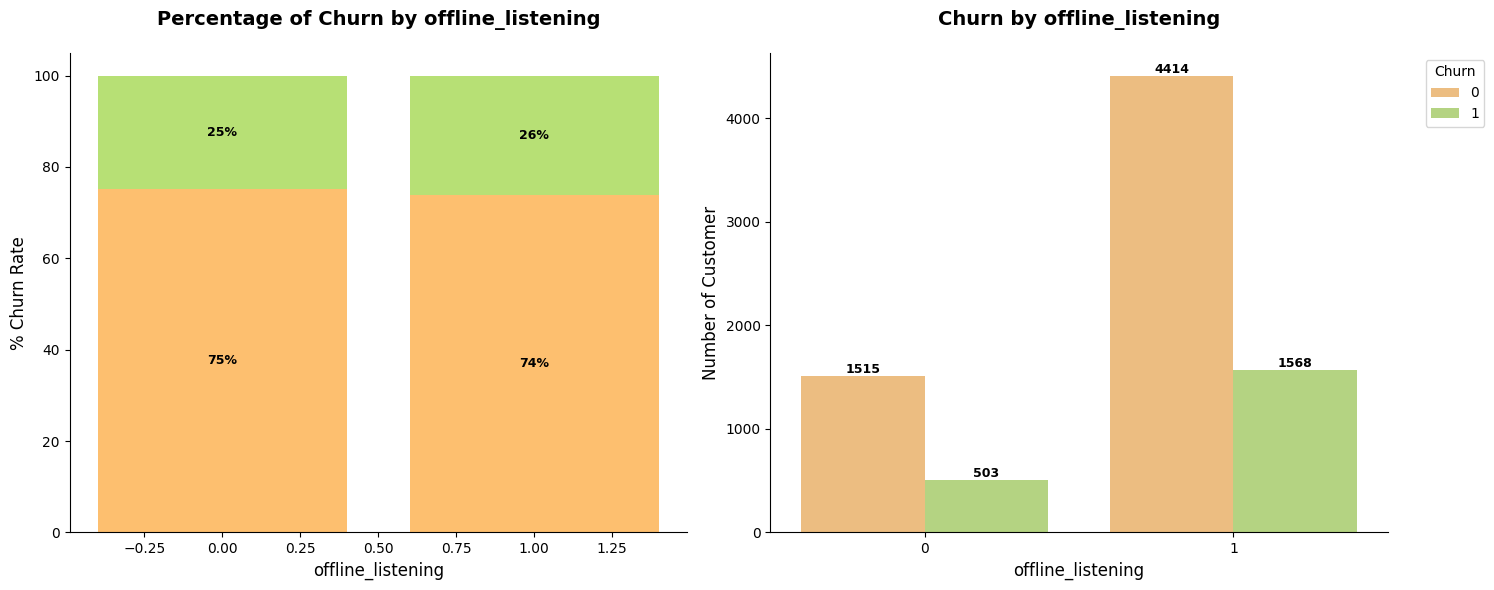


🔍 Chi-Square Test of Independence: 'offline_listening' vs. 'is_churned'
Chi-squared statistic: 1.235
Degrees of freedom: 1
p-value: 0.266412
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'offline_listening' and 'is_churned'.

📈 Standardized Residuals:
is_churned            0     1
offline_listening            
0                  0.50 -0.85
1                 -0.29  0.49


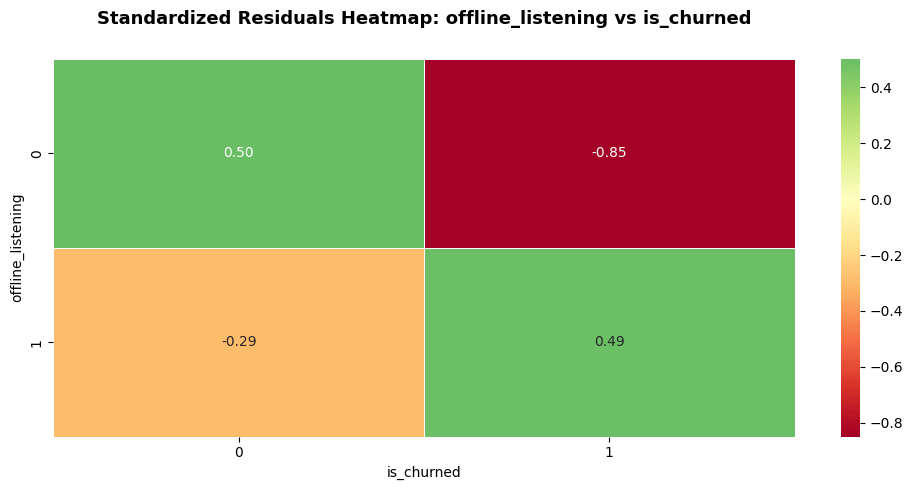

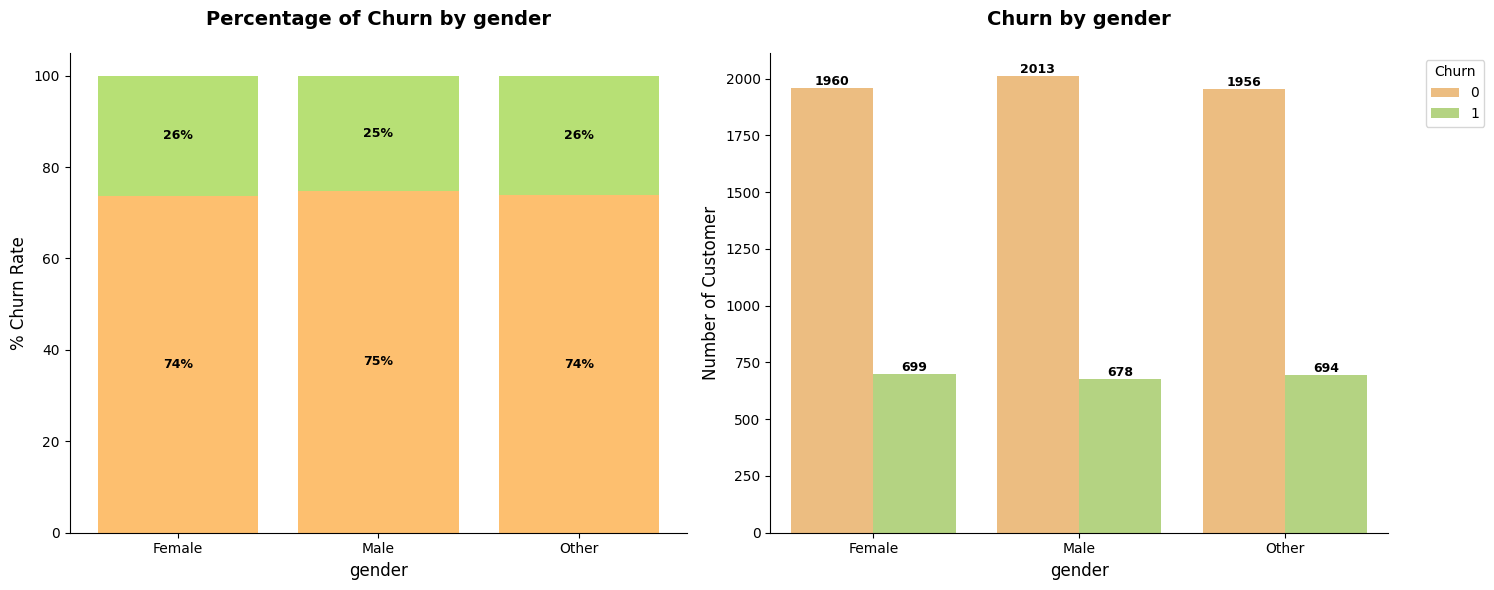


🔍 Chi-Square Test of Independence: 'gender' vs. 'is_churned'
Chi-squared statistic: 1.020
Degrees of freedom: 2
p-value: 0.600461
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'gender' and 'is_churned'.

📈 Standardized Residuals:
is_churned     0     1
gender                
Female     -0.24  0.41
Male        0.42 -0.71
Other      -0.18  0.30


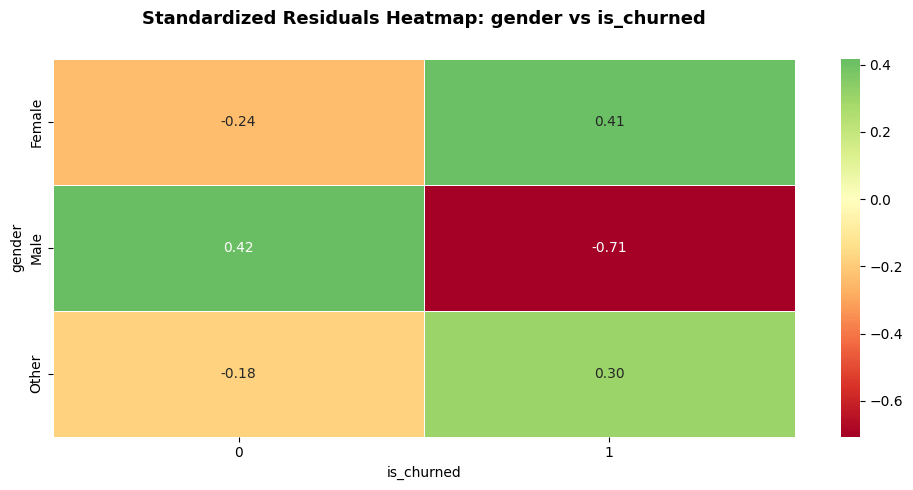

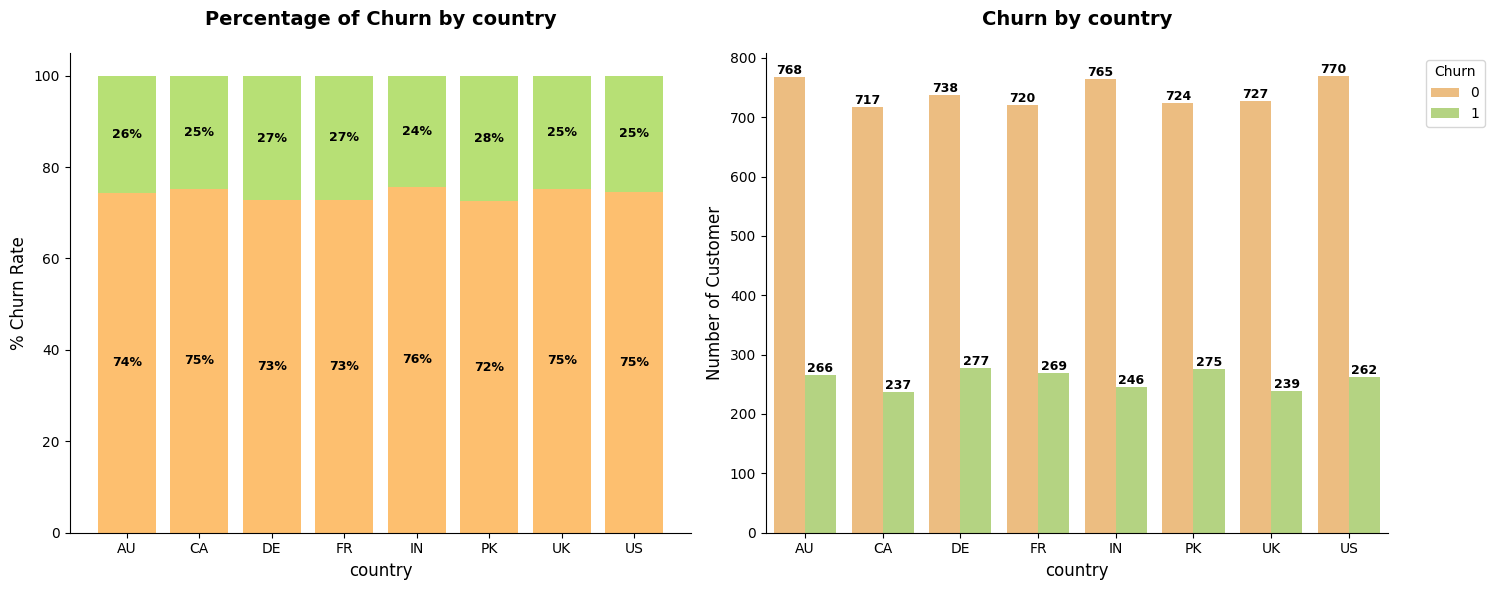


🔍 Chi-Square Test of Independence: 'country' vs. 'is_churned'
Chi-squared statistic: 5.956
Degrees of freedom: 7
p-value: 0.544858
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'country' and 'is_churned'.

📈 Standardized Residuals:
is_churned     0     1
country               
AU          0.06 -0.10
CA          0.37 -0.63
DE         -0.52  0.88
FR         -0.48  0.81
IN          0.57 -0.97
PK         -0.60  1.02
UK          0.41 -0.70
US          0.19 -0.32


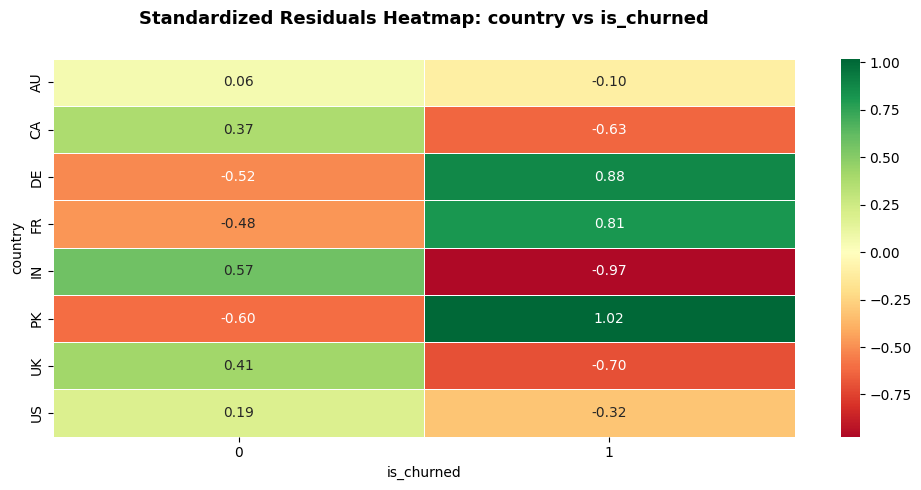

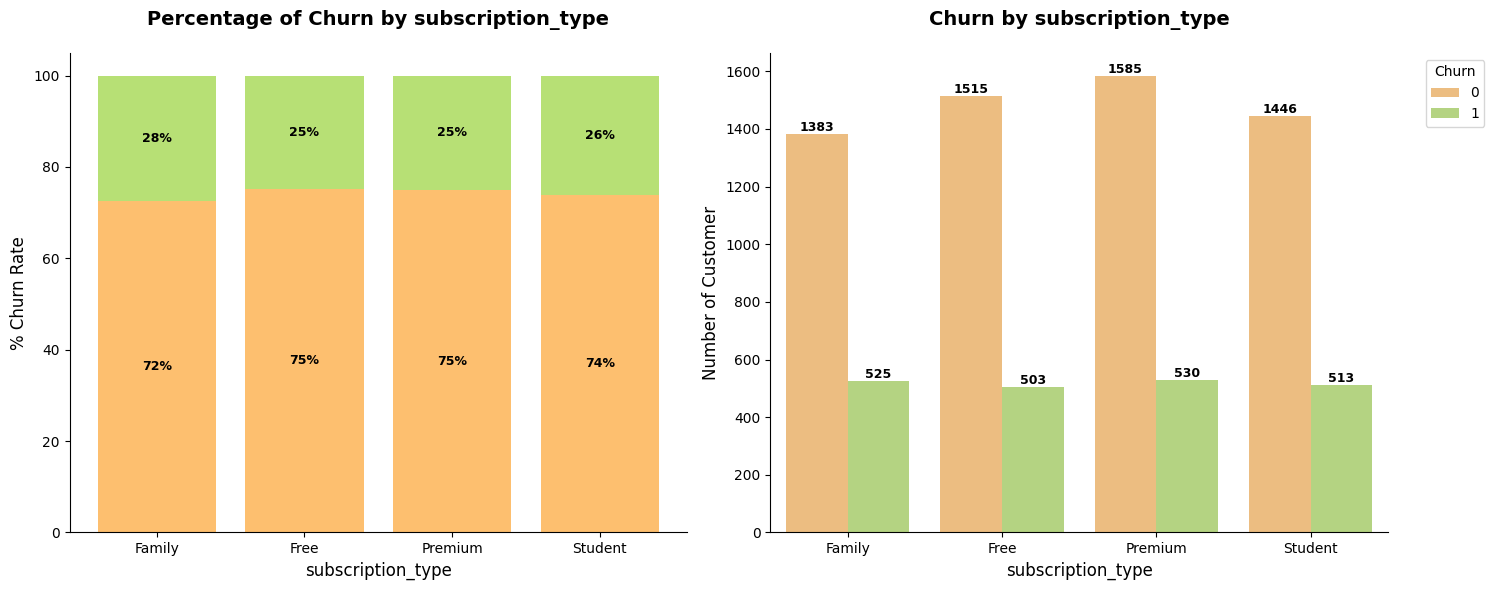


🔍 Chi-Square Test of Independence: 'subscription_type' vs. 'is_churned'
Chi-squared statistic: 4.458
Degrees of freedom: 3
p-value: 0.216111
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'subscription_type' and 'is_churned'.

📈 Standardized Residuals:
is_churned            0     1
subscription_type            
Family            -0.83  1.40
Free               0.50 -0.85
Premium            0.44 -0.75
Student           -0.15  0.26


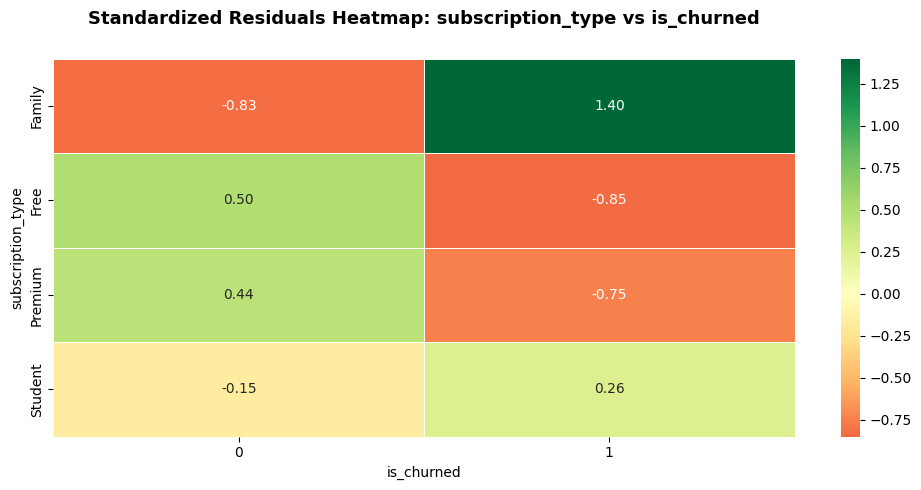

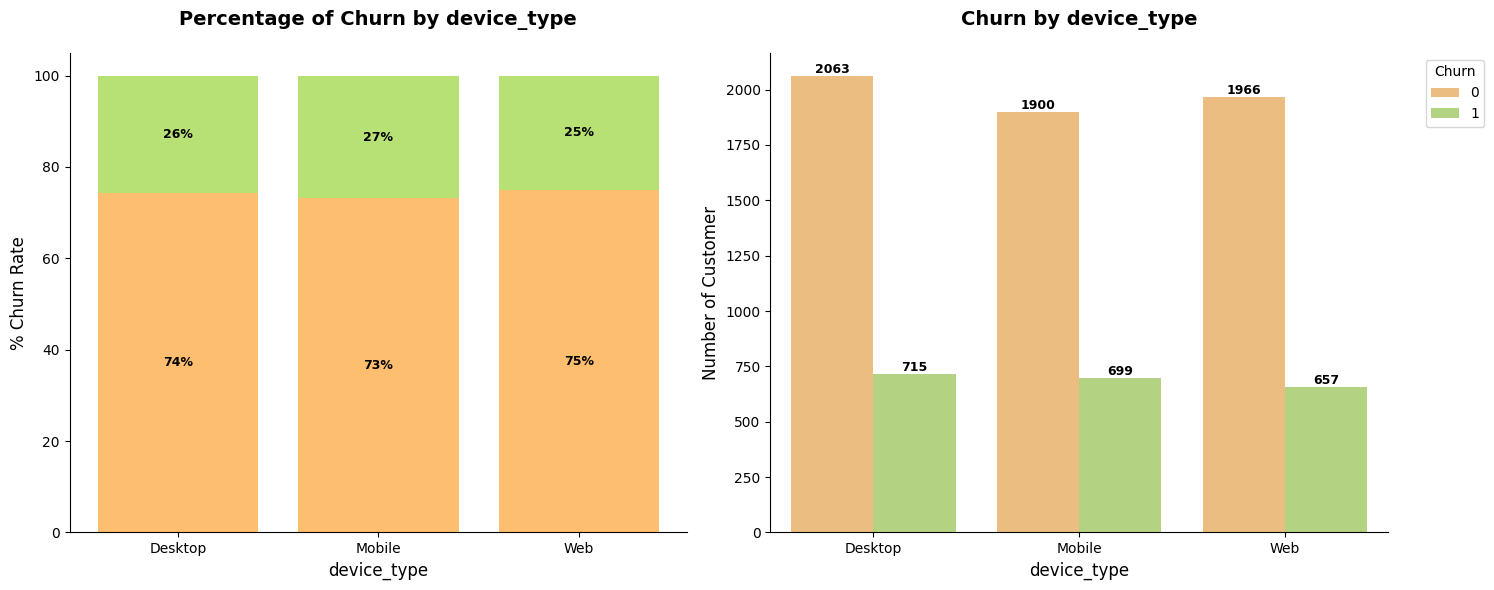


🔍 Chi-Square Test of Independence: 'device_type' vs. 'is_churned'
Chi-squared statistic: 2.372
Degrees of freedom: 2
p-value: 0.305498
❎ Result: p-value ≥ 0.05 → Fail to reject H₀
→ No statistically significant association between 'device_type' and 'is_churned'.

📈 Standardized Residuals:
is_churned      0     1
device_type            
Desktop      0.09 -0.15
Mobile      -0.60  1.01
Web          0.50 -0.85


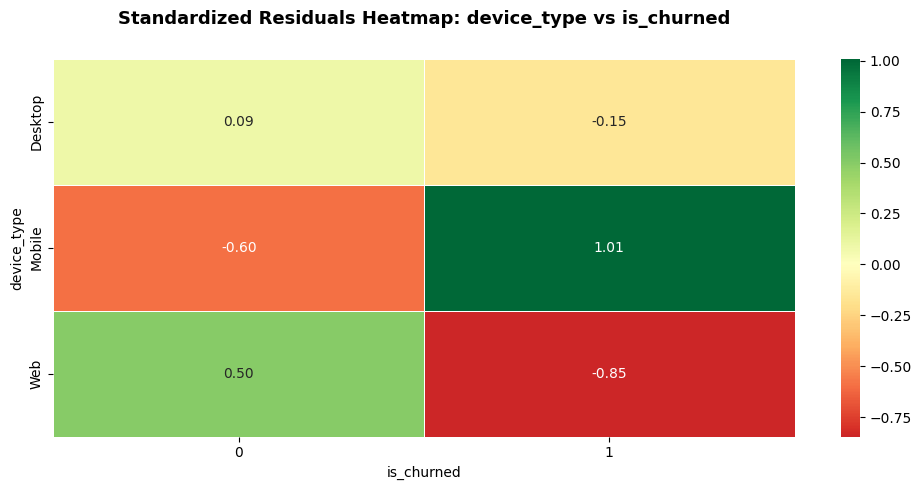

In [20]:
def bivariate_percent_plot(cat, df, figsize=(15, 6), order = None, rot = 0):
    
    display(HTML(f"<h2 style='text-align:center; font-size:22px; color:blue;'><b>Distribution of {cat} by Churn</b></h2>"))
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=figsize)
    # Plot 1
    # Calculate the total number of each "cat" by is_churned
    grouped = df.groupby([cat, "is_churned"]).size().unstack(fill_value=0)
    # Calculate the percentages
    percentages = grouped.div(grouped.sum(axis=1), axis=0) * 100
    if order is not None:
        percentages = percentages.loc[order]
    
    palette = color(n_colors=df["is_churned"].nunique())
    # Convert palette to dict for stacked bar color mapping
    color_map = dict(zip(percentages.columns, palette))
    # Draw stacked bar plot
    bottom = np.zeros(len(percentages))
    for fert in percentages.columns:
        ax[0].bar(percentages.index, percentages[fert], bottom=bottom, label=fert, color=color_map[fert])
        bottom += percentages[fert].values

    for container in ax[0].containers:
        ax[0].bar_label(container, fmt='%1.0f%%', label_type="center", weight="bold", fontsize=9)

    ax[0].set_title(f"Percentage of Churn by {cat}", fontsize=14, weight="bold", pad=20)
    ax[0].set_xlabel(f"{cat}", fontsize=12)
    ax[0].set_ylabel("% Churn Rate", fontsize=12)
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=rot)
    ax[0].legend().remove()
    sns.despine(left=False, bottom=False, ax=ax[0])

    # Plot 2
    sns.countplot(data=df, hue = "is_churned", x = cat,
                palette=color(n_colors=2), ax=ax[1], order=percentages.index)
    # Show value for each bar.
    for container in ax[1].containers:
        ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=9, weight="bold")

    ax[1].set_title(f"Churn by {cat}", fontsize=14, weight="bold", pad=20)
    ax[1].set_xlabel(f"{cat}", fontsize=12)
    ax[1].set_ylabel("Number of Customer", fontsize=12)
    ax[1].legend(title="Churn", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=rot)
    sns.despine(left=False, bottom=False, ax=ax[1])
    plt.tight_layout()
    plt.show()

    cal_ChiSquare(cat_feature=cat, target_feature="is_churned", df=df, show_residuals=True)

for feature in cat_features:
    bivariate_percent_plot(cat=feature, df= df)

**Insight for Categorical Features by Churn**

`offline_listening`

Offline listening does **not significantly influence churn** — Premium and Free users appear evenly distributed across churn outcomes.

`gender` 

Gender has **no meaningful influence** on user churn — Spotify’s retention appears consistent across all gender groups.

`country`

Churn behavior is **consistent across countries** — geographic region does **not significantly influence** user retention in this dataset.

`subscription_type`

Churn behavior is **not significantly influenced** by subscription type — while minor variations exist, all plan categories exhibit broadly similar retention rates.

`device_type`

Device type has **no statistically meaningful impact** on churn — Spotify users appear equally likely to stay or leave regardless of their primary listening platform.

### 📊 Summary of Insights by Feature Type

| **Feature Type** | **Feature**             | **Insight Summary**                                                                                                     |
| ---------------- | ----------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| **Categorical**  | `offline_listening`     | Offline listening does **not significantly influence churn** — Premium and Free users appear evenly distributed.        |
|                  | `gender`                | Gender has **no meaningful influence** — retention is consistent across all gender groups.                              |
|                  | `country`               | Churn behavior is **consistent across countries** — geographic region does **not significantly affect** user retention. |
|                  | `subscription_type`     | **No significant churn difference** among subscription types — minor variations, but not statistically meaningful.      |
|                  | `device_type`           | Device type shows **no statistical impact** on churn — similar stay/leave behavior across devices.                      |
| **Numerical**    | `age`                   | Age has **no significant correlation** with churn — similar distribution among churned and active users.                |
|                  | `listening_time`        | Listening time does **not differ significantly** — churned and active users spend comparable listening hours.           |
|                  | `songs_played_per_day`  | Daily song play frequency has **no meaningful influence** on churn — usage levels are similar.                          |
|                  | `ads_listened_per_week` | Exposure to ads shows **no significant difference** — ad frequency is **not a key churn driver**.                       |

**General Interpretation**

* Across both **categorical** and **numerical** variables, **no statistically significant predictors** of churn were found in this dataset.
* All p-values ≥ 0.05 and standardized residuals / Cohen’s *d* were within small-effect ranges → suggesting **weak or no association** between individual variables and churn status.
* This indicates that:

  * The dataset is **synthetic / randomized**, leading to weak signal strength.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Re-checking Skew

In [21]:
skew_feature, skew_df = check_skewness(data=df, numerical_features=num_features)


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
ads_listened_per_week               |  +1.799745 | Highly skewed
age                                 |  -0.027435 | Approximately symmetric
listening_time                      |  +0.009674 | Approximately symmetric
songs_played_per_day                |  -0.003661 | Approximately symmetric
---------------------------------------------------------------------------


In [22]:
from sklearn.preprocessing import PowerTransformer

def handle_skewed_features(
    df,
    zero_threshold=0.9,
    skew_threshold=0.5,
    num_features=None,
    exclude_cols=None    
):
    """
    Handle skewed numerical features by applying appropriate transformations.

    Parameters:
    - df: pandas.DataFrame
    - zero_threshold: float (default=0.9)
    - skew_threshold: float (default=0.5)
    - num_features: list of numerical columns to consider
    - exclude_cols: list of columns to skip entirely

    Returns:
    - df: transformed DataFrame
    - transformed_cols: list of new feature names
    - high_zero_cols: list of sparse features (> zero_threshold)
    - skewed_cols: list of auto‑detected skewed features
    """
    df = df.copy()
    if num_features is None:
        raise ValueError("`num_features` must be provided")
    if exclude_cols is None:
        exclude_cols = []

    # 1) pick the numeric cols to scan
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # 2) detect ultra‑sparse
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # 3) compute skew
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # 4) union these with your forced list
    to_transform = list(set(auto_skewed))

    transformed_cols = []
    dropped_cols     = []

    for col in to_transform:
        # if it's sparse → binary+log
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x) if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)
        # if it's discrete small‑cardinality, skip transform but keep
        elif df[col].nunique() <= 5:
            # do nothing (we still keep raw col in df)
            continue
        # otherwise apply Yeo‑Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # drop originals for any column we did transform
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed

In [23]:
processed_df, transformed_columns, sparse_columns, skewed_columns = handle_skewed_features(df=df, num_features=skew_feature)
num_features = ["age", "listening_time", "songs_played_per_day", "PT_ads_listened_per_week"]
skew_feature, skew_df = check_skewness(data=processed_df, numerical_features=num_features)


🔍 Skewness for dataset:
---------------------------------------------------------------------------
Feature                             | Skewness   | Remark
---------------------------------------------------------------------------
PT_ads_listened_per_week            |  +1.144996 | Highly skewed
age                                 |  -0.027435 | Approximately symmetric
listening_time                      |  +0.009674 | Approximately symmetric
songs_played_per_day                |  -0.003661 | Approximately symmetric
---------------------------------------------------------------------------


**Insights on Skewness Before and After Yeo–Johnson Transformation**

* Before transformation, **`ads_listened_per_week`** showed a **strong right skew**, indicating that most users hear very few ads while a small group experiences a high number of ads.
* After applying the **Yeo–Johnson transformation**, the skewness decreased substantially (**from +1.80 → +1.14**), leading to a **more normalized distribution**, suitable for linear modeling.
* The other variables (`age`, `listening_time`, `songs_played_per_day`) were already **approximately symmetric**, so the transformation had little or no impact.

## Re-check Outliers

In [24]:
checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data")

🔍 Data Checking outlier
✅ No outliers detected in the selected features.


## Create Test Set

🔴 Suppose you chatted with experts who told you that the **listening_time** is a very important attribute to predict **Churn**. <br>
🔴 We may want to ensure that the test set is representative of the various categories of total charge in the whole dataset. Since the total charge is a continuous numerical attribute, we first need to create an category attribute.

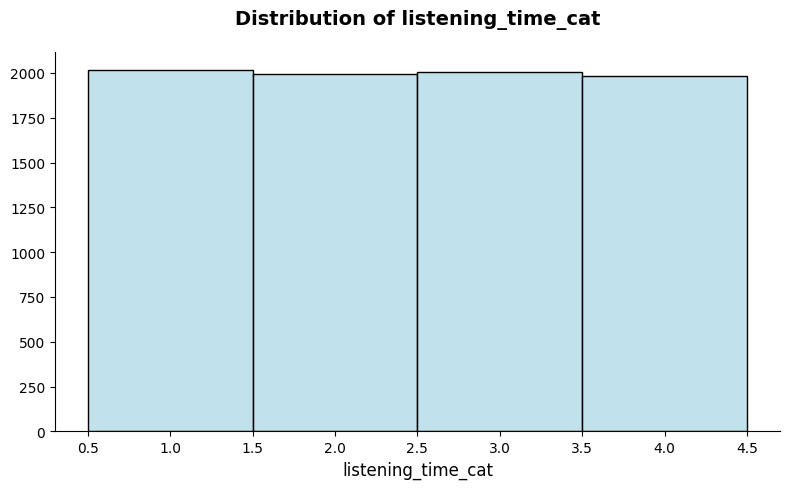

In [25]:
processed_df["listening_time_cat"] = pd.qcut(processed_df["listening_time"],
                                              q=4,
                                              labels=[1, 2, 3, 4])

plt.figure(figsize=(8, 5))
sns.histplot(data=processed_df, x="listening_time_cat", color="lightblue", edgecolor="black")
sns.despine(top=True, right=True, left=False, bottom=False)
plt.title("Distribution of listening_time_cat", fontsize=14, weight="bold",pad=20)
plt.xlabel("listening_time_cat", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [26]:
split = StratifiedShuffleSplit(n_splits=Config.N_SPLIT, test_size=Config.TEST_SIZE, random_state=Config.SEED)
for train_index, val_index in split.split(processed_df, processed_df["listening_time_cat"]):
    start_train_set = processed_df.loc[train_index]
    start_val_set = processed_df.loc[val_index]

# Now we should remove the listening_time_cat attribute so the data is back to its original state:
for set_ in (start_train_set, start_val_set): 
    set_.drop("listening_time_cat", axis=1, inplace=True)

## Scale and Encode

In [27]:
df_new = start_train_set.drop("is_churned", axis=1)
df_label = start_train_set["is_churned"].copy()

num_transfomer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transfomer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transfomer, num_features),
        ("cat", cat_transfomer, cat_features),
    ]
)

preprocessor.fit(df_new)

df_train_new_prepared = preprocessor.transform(df_new)
list_feature_prepared = preprocessor.get_feature_names_out().tolist()
clean_features = [col.replace("num__", "").replace("cat__", "").replace("PT_", "") for col in list_feature_prepared]

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Define Metric</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Define Metric
    </h1>
</div>

| Metric        | Definition                                                  | Meaning in Attrition Context                                          |
| ------------- | ----------------------------------------------------------- | --------------------------------------------------------------------- |
| **Recall**    | $\frac{TP}{TP + FN}$                                        | **Most important** – how many true leavers you can catch              |
| **Precision** | $\frac{TP}{TP + FP}$                                        | Among predicted leavers, how many are actually correct                |
| **Accuracy**  | $\frac{TP + TN}{Total}$                                     | Can be misleading with imbalanced data (e.g., <20% attrition)         |
| **F1-score**  | $\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}$ | Balanced trade-off between Precision and Recall                       |
| **AUC-ROC**   | Area under ROC Curve                                        | Measures ability to distinguish leavers vs. stayers at all thresholds |


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation Using Cross-Validation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation Using Cross-Validation
    </h1>
</div>

In [28]:
# Using SMOTE to handling imbalance data.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=Config.SEED)
X_resampled, y_resampled = smote.fit_resample(df_train_new_prepared, df_label)

In [29]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              ExtraTreesClassifier, AdaBoostClassifier, BaggingClassifier,
                              HistGradientBoostingClassifier)
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=Config.SEED)
models = [
    LinearSVC(random_state=Config.SEED),
    SVC(random_state=Config.SEED),
    KNeighborsClassifier(),
    GaussianNB(),
    LogisticRegression(random_state=Config.SEED),
    DecisionTreeClassifier(random_state=Config.SEED),
    RandomForestClassifier(random_state=Config.SEED),
    ExtraTreesClassifier(random_state=Config.SEED),
    AdaBoostClassifier(random_state=Config.SEED),
    XGBClassifier(random_state=Config.SEED),
    MLPClassifier(random_state=Config.SEED, max_iter=Config.MAX_ITER),
    GradientBoostingClassifier(random_state=Config.SEED),
    RidgeClassifier(random_state=Config.SEED),
    CatBoostClassifier(verbose=0, random_seed=Config.SEED),
    BaggingClassifier(random_state=Config.SEED),
    LGBMClassifier(random_state=Config.SEED, verbosity=-1),
    HistGradientBoostingClassifier(random_state=Config.SEED)
]

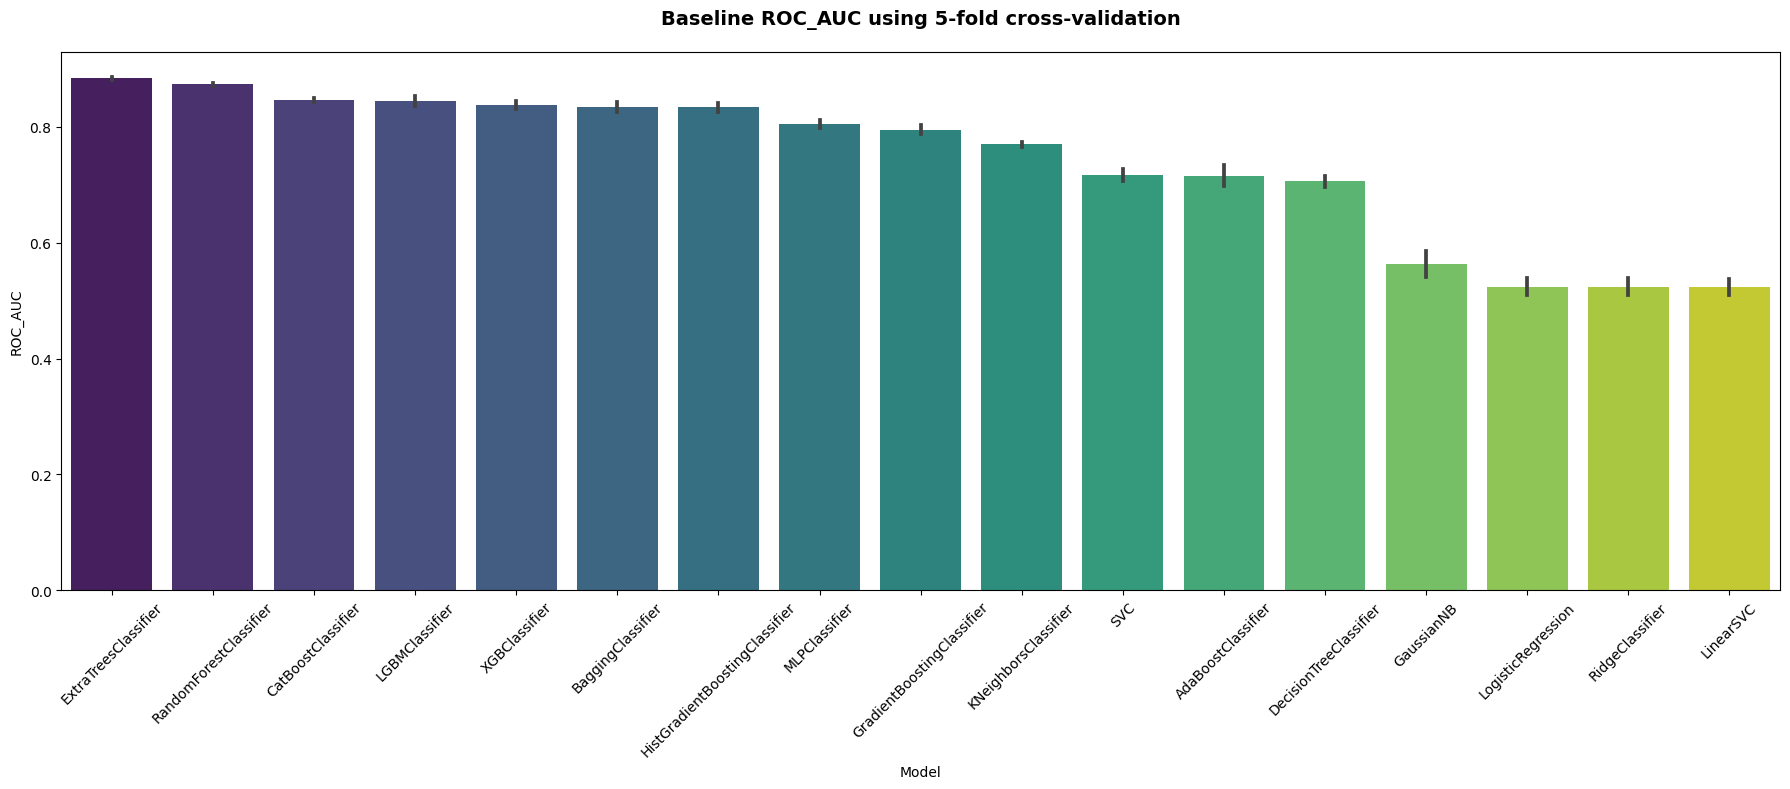

,Mean,Std,N
model_name,,,
ExtraTreesClassifier,0.883751,0.001806,5
RandomForestClassifier,0.873788,0.002248,5
CatBoostClassifier,0.846622,0.004237,5
LGBMClassifier,0.844604,0.008027,5
XGBClassifier,0.838474,0.006828,5
BaggingClassifier,0.834914,0.008460,5
HistGradientBoostingClassifier,0.833639,0.008083,5
MLPClassifier,0.804614,0.007208,5
GradientBoostingClassifier,0.795137,0.007460,5


In [30]:
def generate_baseline_results(models=models, X=X_resampled, y=y_resampled,
                              metric="roc_auc", cv=kfold, plot_result=False):
    entries = []
    for model in models:
        model_name = getattr(model, "name", model.__class__.__name__)
        scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
        for fold_idx, s in enumerate(scores, start=1):
            entries.append((model_name, fold_idx, s))

    cv_df = pd.DataFrame(entries, columns=["model_name", "fold_id", "score"])

    summary = (cv_df.groupby("model_name")["score"]
                    .agg(Mean="mean", Std="std", N="size")
                    .sort_values("Mean", ascending=False))

    if plot_result:
        order = summary.index.tolist()
        plt.figure(figsize=(18, 8))
        sns.barplot(data=cv_df, x="model_name", y="score", order=order, errorbar=("sd"), palette="viridis")
        title_metric = metric.upper() if isinstance(metric, str) else "Score"
        nfolds = getattr(cv, "n_splits", "CV")
        plt.title(f"Baseline {title_metric} using {nfolds}-fold cross-validation", fontsize=14, weight="bold", pad=20)
        plt.xlabel("Model"); plt.ylabel(title_metric)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return summary

display(generate_baseline_results(plot_result = True))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Hyperparameter tuning</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Hyperparameter tuning
    </h1>
</div>

In [31]:
def shap_plot(model, X_test, list_feature, type = None):
     # https://towardsdatascience.com/using-shap-values-to-explain-how-your-machine-learning-model-works-732b3f40e137/
    if hasattr(X_test, "toarray"):
        X_test = X_test.toarray()
    X_test_sample = pd.DataFrame(X_test, columns=list_feature)
    explainer = shap.Explainer(model.predict, X_test_sample)
    shap_values = explainer(X_test_sample)
    if type =="bar":
        shap_importance = np.abs(shap_values.values).mean(axis=0)
        shap_df = pd.DataFrame({"feature": X_test_sample.columns, "importance": shap_importance})
        shap_df = shap_df.sort_values("importance", ascending=False).head(20)
        plt.figure(figsize=(12, 6))
        sns.barplot(x=shap_df["importance"], y=shap_df["feature"], palette="viridis", order=shap_df["feature"])
        plt.xlabel("mean(|SHAP value|)")
        plt.title("SHAP Feature Importance", fontsize=14, weight="bold", pad=20)
        plt.tight_layout()
        plt.show()
    else:
        shap.summary_plot(shap_values, X_test_sample)

In [32]:
def plot_ROC_confusionMatrix(estimator, X_val, y_val, figsize):
    y_pred_prob = estimator.predict_proba(X_val)[:, 1]  # Probability of positive class
    y_pred = estimator.predict(X_val)

    fig, ax = plt.subplots(nrows=2, ncols=2, sharey=False, figsize=figsize)

    # Plot 1
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    rocScore = roc_auc_score(y_val, y_pred_prob)

    ax[0, 0].plot(fpr, tpr, label=f"{estimator.__class__.__name__} (AUC = {rocScore:.2f})")
    ax[0, 0].plot([0, 1], [0, 1], "b--")
    ax[0, 0].set_xlabel("False Positive Rate")
    ax[0, 0].set_ylabel("True Positive Rate")
    ax[0, 0].set_title(f"ROC ({estimator.__class__.__name__})", fontsize=14, weight="bold", pad=20)
    ax[0, 0].legend()

    # Plot 2
    confusionMatrix = confusion_matrix(y_val, y_pred)
    sns.heatmap(confusionMatrix, annot=True, fmt="d", cmap="Blues", ax=ax[0, 1])
    ax[0, 1].set_title(f"Confusion Matrix ({estimator.__class__.__name__})", fontsize=14, weight="bold", pad=20)
    ax[0, 1].set_xlabel("Prediction")
    ax[0, 1].set_ylabel("Actual")

    # plot 3
    avg_prec = average_precision_score(y_val, y_pred_prob)   
    precision, recall, thresholds_pr = precision_recall_curve(y_val, y_pred_prob)
    ax[1, 0].plot(recall, precision, label=f"PR Curve (AP = {avg_prec:.3f})")
    ax[1, 0].set_xlabel("Recall")
    ax[1, 0].set_ylabel("Precision")
    ax[1, 0].set_title("Precision-Recall Curve", fontsize=14, weight="bold", pad=20)
    ax[1, 0].legend()

    ax.flat[-1].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(classification_report(y_val, y_pred))

In [33]:
# Function to evaluate models
def evaluate_model(model, X_train, X_val, y_train, y_val, figsize = (15, 6), show_shap_plot = False):
    print(f"Evaluating {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    plot_ROC_confusionMatrix(estimator = model, X_val = X_val, y_val = y_val, figsize = figsize)
    if show_shap_plot:
        shap_sample = X_val.iloc[:200] if isinstance(X_val, pd.DataFrame) else X_val[:200]
        shap_plot(model=model, X_test=shap_sample, list_feature=list_feature_prepared)

In [34]:
X_val = start_val_set.drop("is_churned", axis=1)
y_val = start_val_set["is_churned"].copy()
X_val_prepared = preprocessor.transform(X_val)

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_etc = {
"n_estimators": 400,
"max_depth": 20,
"min_samples_split": 2,
"min_samples_leaf": 1,
"max_features": "sqrt",
"bootstrap": False,
"criterion": "log_loss",
"random_state": Config.SEED
}
model_etc = ExtraTreesClassifier(**param_etc)

param_rf = {
"n_estimators": 300,
"max_depth": 20,
"min_samples_split": 4,
"min_samples_leaf": 1,
"max_features": "sqrt",
"bootstrap": True,
"criterion": "entropy",
"random_state": 42,
"n_jobs":-1
}
model_rf = RandomForestClassifier(**param_rf)

param_lgbm = {
"boosting_type": "gbdt",
"num_leaves": 250,
"max_depth": 10,
"learning_rate": 0.045178997444718726,
"n_estimators": 200,
"min_child_samples": 10,
"subsample": 0.782964614940435,
"colsample_bytree": 0.7330716143099598,
"reg_alpha": 0.24890188410341635,
"reg_lambda": 0.004657445631362826,
"objective": "binary",
"metric": "auc",
"random_state": 42,
"verbosity": -1,
"n_jobs": -1
}
model_lgbm = LGBMClassifier(**param_lgbm)

param_xgb = {
"max_depth": 12,
"learning_rate": 0.07817696505802245,
"n_estimators": 400,
"min_child_weight": 1,
"gamma": 0.48090088564824013,
"subsample": 0.7405374966342305,
"colsample_bytree": 0.9486795718112047,
"reg_alpha": 0.42126886411754005,
"reg_lambda": 0.029619662998753345,
"objective": "binary:logistic",
"eval_metric": "auc",
"booster": "gbtree",
"random_state": 42,
"use_label_encoder": False,
"n_jobs": -1
}
model_xgb = XGBClassifier(**param_xgb)

param_cb = {
"bootstrap_type": "Bayesian",
"iterations": 1000,
"depth": 10,
"learning_rate": 0.018204862421694255,
"l2_leaf_reg": 0.03747164994076259,
"border_count": 171,
"grow_policy": "SymmetricTree",
"random_strength": 0.6053020767776336,
"bagging_temperature": 1.0703451569636622,
"eval_metric": "AUC",
"verbose": 0,
"random_seed": 42,
"thread_count": -1,
"task_type": "CPU"
}
model_cb = CatBoostClassifier(**param_cb)

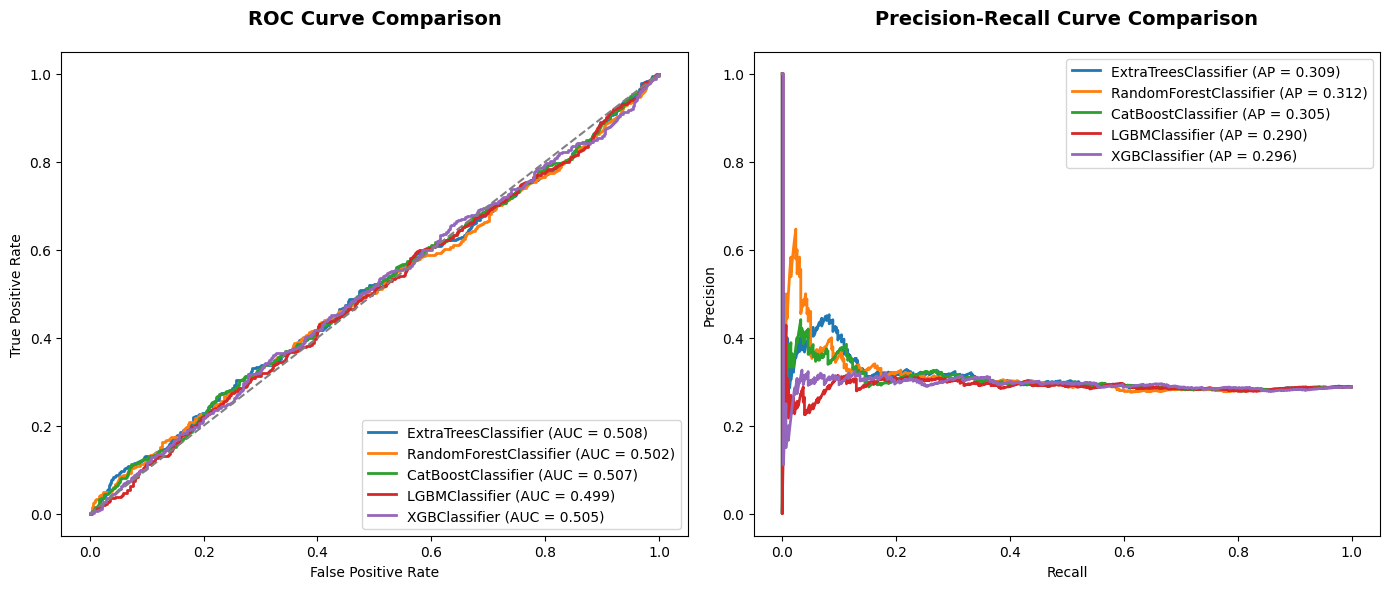

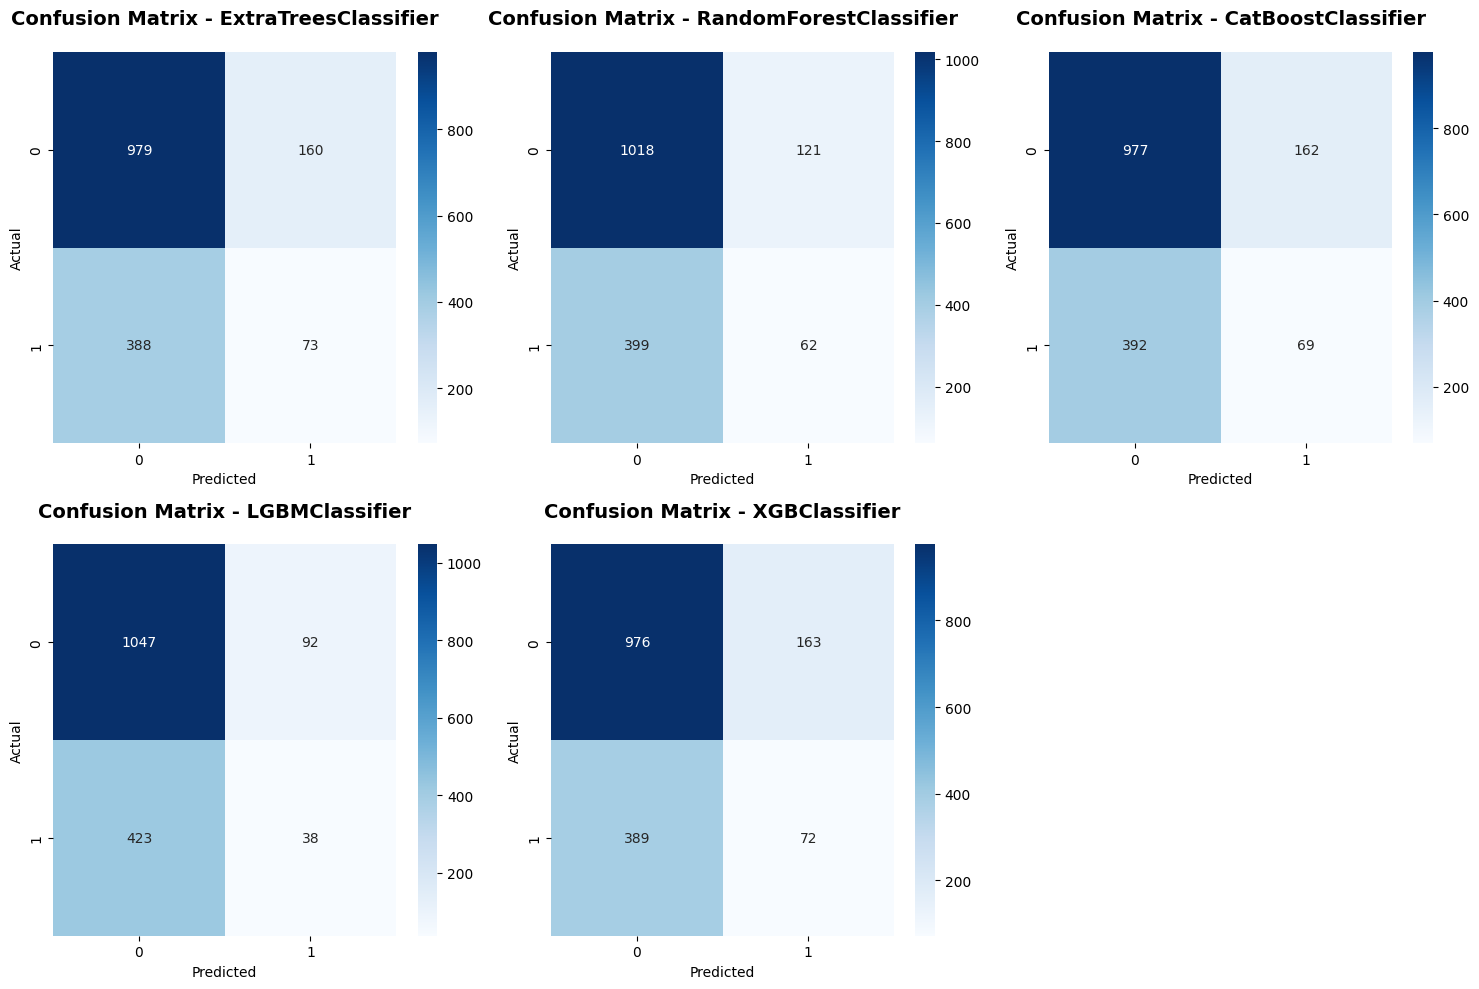

Classification Report - ExtraTreesClassifier
              precision    recall  f1-score   support

           0      0.716     0.860     0.781      1139
           1      0.313     0.158     0.210       461

    accuracy                          0.657      1600
   macro avg      0.515     0.509     0.496      1600
weighted avg      0.600     0.657     0.617      1600

Classification Report - RandomForestClassifier
              precision    recall  f1-score   support

           0      0.718     0.894     0.797      1139
           1      0.339     0.134     0.193       461

    accuracy                          0.675      1600
   macro avg      0.529     0.514     0.495      1600
weighted avg      0.609     0.675     0.623      1600

Classification Report - CatBoostClassifier
              precision    recall  f1-score   support

           0      0.714     0.858     0.779      1139
           1      0.299     0.150     0.199       461

    accuracy                          0.654    

In [36]:
models = {
    "ExtraTreesClassifier": model_etc,
    "RandomForestClassifier": model_rf,
    "CatBoostClassifier": model_cb,
    "LGBMClassifier": model_lgbm,
    "XGBClassifier": model_xgb
}

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
prec_dict, rec_dict, pr_auc_dict = {}, {}, {}
y_pred_dict = {}
y_pred_proba_dict = {}

for name, model in models.items():
    model.fit(X_resampled, y_resampled)
    y_pred = model.predict(X_val_prepared)
    y_pred_proba = model.predict_proba(X_val_prepared)[:, 1]
    
    y_pred_dict[name] = y_pred
    y_pred_proba_dict[name] = y_pred_proba

    # --- ROC ---
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    fpr_dict[name], tpr_dict[name], roc_auc_dict[name] = fpr, tpr, roc_auc

    # --- Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_val, y_pred_proba)
    prec_dict[name], rec_dict[name] = precision, recall

# --- ROC & Precision-Recall Curve on the same figure ---
fig, ax = plt.subplots(1, 2, figsize=(14,6))

# ROC Curve
for name in models.keys():
    ax[0].plot(fpr_dict[name], tpr_dict[name], lw=2,
                 label=f"{name} (AUC = {roc_auc_dict[name]:.3f})")
ax[0].plot([0,1], [0,1], color="gray", linestyle="--")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve Comparison", fontsize=14, weight="bold", pad=20)
ax[0].legend(loc="lower right")

# Precision-Recall Curve
for name in models.keys():
    avg_prec = average_precision_score(y_val, y_pred_proba_dict[name])
    ax[1].plot(rec_dict[name], prec_dict[name], lw=2,
                 label=f"{name} (AP = {avg_prec:.3f})")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curve Comparison", fontsize=14, weight="bold", pad=20)
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

# --- Confusion Matrices ---
fig, ax = plt.subplots(2, 3, figsize=(15,10))
ax = ax.ravel()
for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_val, y_pred_dict[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[i])
    ax[i].set_title(f"Confusion Matrix - {name}", fontsize=14, weight="bold", pad=20)
    ax[i].set_xlabel("Predicted")
    ax[i].set_ylabel("Actual")
ax.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

# --- Classification Reports ---
for name in models.keys():
    print("="*50)
    print(f"Classification Report - {name}")
    print(classification_report(y_val, y_pred_dict[name], digits=3))

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Conclusion</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Conclusion
    </h1>
</div>

In [37]:
# Collect predictions (probabilities instead of labels) ---
ests = [
    ("cb", model_cb),
    ("xgb", model_xgb),
    ("lgbm", model_lgbm),
    ("rf", model_rf),
    ("etc", model_etc)
]

preds = {name: m.predict_proba(X_val_prepared)[:, 1] for name, m in ests}

auc_each = {name: roc_auc_score(y_val, preds[name]) for name,_ in ests}
display(auc_each)

A = np.column_stack([preds[name] for name,_ in ests])  # shape (n_val, n_models)
def obj_w(trial):
    w = np.array([trial.suggest_float(f"w_{i}", 0.0, 5.0) for i in range(A.shape[1])])
    if w.sum() == 0: 
        return 1e6
    y_hat = A.dot(w / w.sum())  # weighted average probs
    return roc_auc_score(y_val, y_hat)

study_w = optuna.create_study(direction="maximize")  
study_w.optimize(obj_w, n_trials=1000, show_progress_bar=True)

w = np.array([study_w.best_params[f"w_{i}"] for i in range(A.shape[1])])
weights = (w / w.sum()).tolist()
print("Best weights (normalized):", weights)
print("Best AUC:", study_w.best_value)

{'cb': 0.5071408302369739,
 'xgb': 0.5049906775932764,
 'lgbm': 0.4994372275409986,
 'rf': 0.5020349318864399,
 'etc': 0.5078511995337844}

  0%|          | 0/1000 [00:00<?, ?it/s]

Best weights (normalized): [0.06446663627538413, 0.27207133945140316, 6.938760845931495e-05, 0.0008381019121703807, 0.6625545347525831]
Best AUC: 0.5101308564996886


In [38]:
from sklearn.ensemble import VotingClassifier
voting_clf_soft = VotingClassifier(
    estimators=[
        ("etc", model_etc),
        ("rf", model_rf),
        ("cb", model_cb),
        ("lgbm", model_lgbm),
        ("xgb", model_xgb),
    ], weights=weights,
    voting="soft",
    n_jobs=-1
)

cv_scores = cross_val_score(
    voting_clf_soft,
    X=X_resampled,
    y=y_resampled,
    cv=kfold,
    scoring="roc_auc",
    n_jobs=-1
)
print(f"Cross-validated ROC-AUC (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validated ROC-AUC (mean ± std): 0.8706 ± 0.0031


Evaluating VotingClassifier...


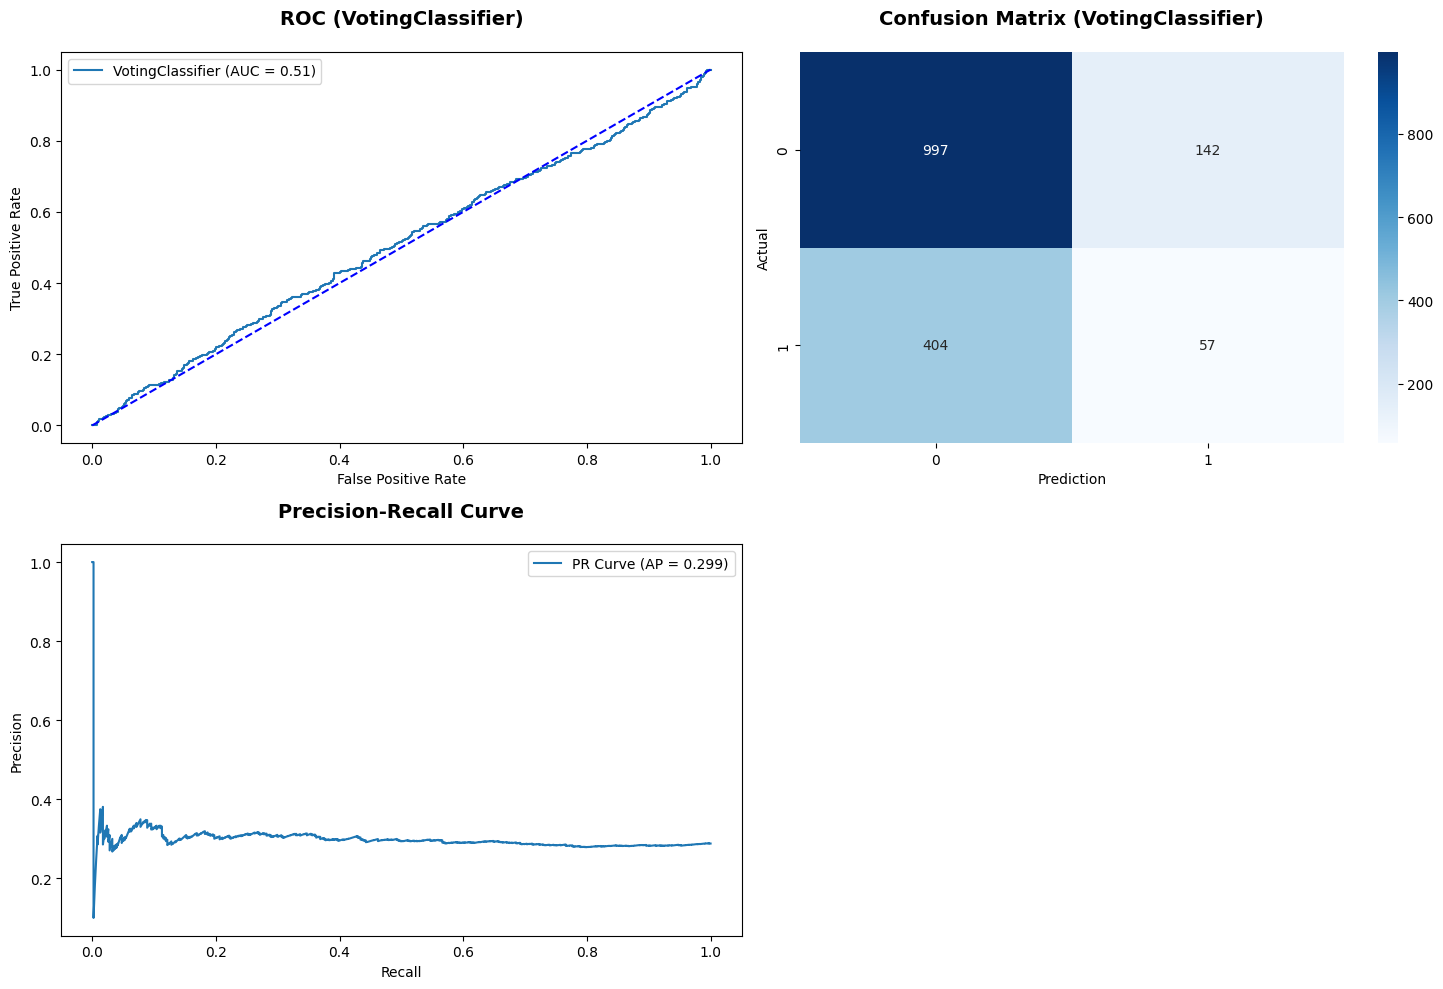

              precision    recall  f1-score   support

           0       0.71      0.88      0.79      1139
           1       0.29      0.12      0.17       461

    accuracy                           0.66      1600
   macro avg       0.50      0.50      0.48      1600
weighted avg       0.59      0.66      0.61      1600



In [39]:
evaluate_model(model = voting_clf_soft, X_train=X_resampled, X_val=X_val_prepared,
               y_train=y_resampled, y_val=y_val, figsize=(15, 10))

PermutationExplainer explainer: 301it [07:29,  1.52s/it]


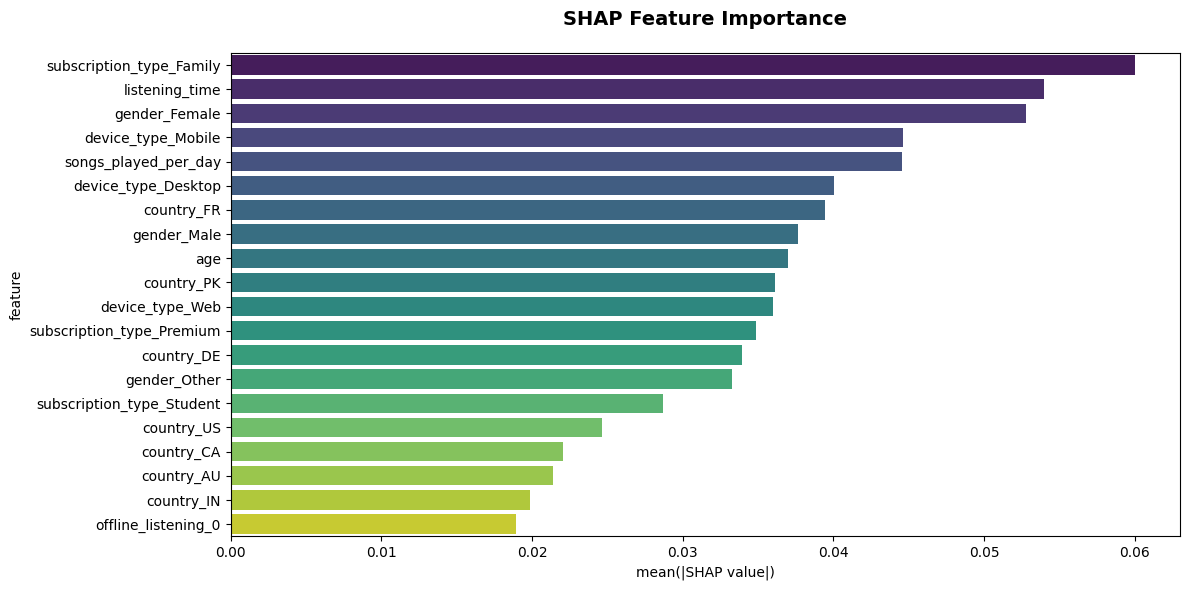

In [40]:
shap_sample = X_val_prepared.iloc[:300] if isinstance(X_val_prepared, pd.DataFrame) else X_val_prepared[:300]
shap_plot(model=voting_clf_soft.named_estimators_["etc"], X_test=shap_sample, list_feature=clean_features, type="bar")

**SHAP Feature Importance Insights**

* **Top Drivers of Churn Prediction:**

  * `gender_Female`, `subscription_type_Family`, and `device_type_Mobile` have the strongest impact.
  * Female users and Family Plan subscribers show **lower churn tendency**.

* **Behavioral Patterns:**

  * Higher `listening_time` and `songs_played_per_day` → **lower churn** (more engagement = more loyalty).

* **Device Influence:**

  * Mobile users are generally **more retained** compared to Web or Desktop users.

* **Subscription Plans:**

  * Family and Premium plans reduce churn risk, while Free and Student users are **more likely to churn**.

* **Country & Offline Listening:**

  * Minor impact; user churn appears **consistent across countries** and not affected by offline listening.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #003366, #336699 30%, #66ccff 70%, #99ccff); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
